# 1. Imports and definiiton

In [1]:
# import the library
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import calendar
import numpy as np
import matplotlib.dates as mdates
import sys
import os
from os import listdir
from os.path import isfile, join
from dateutil import parser
import re
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (GradientBoostingRegressor, 
                              RandomForestRegressor, 
                              AdaBoostRegressor, 
                              BaggingRegressor, 
                              ExtraTreesRegressor,
                              HistGradientBoostingRegressor,
                              StackingRegressor,
                              VotingRegressor)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.colors as mcolors
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from datetime import datetime, timedelta
from matplotlib import animation
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
# from func_defs import *

# %matplotlib ipympl
# %matplotlib inline


# define the inverter to analyse
inverter = '2-1'


# define the plot template
axis_label_size = 15
axis_num_size = 12
text_size = 12
title_size = 22

# define the figure size for single plot
figure_size = (6, 6)
subplot_size_1_2 = (6, 6)
long_hoz_figsize = (12, 6)

# Load the data from the pickle file
data_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\full_inv_pow_5min.pkl"
# Define SunSolve Yield CSV file path - user can modify this directly
# sunsolve_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\SunSolve Yield\Per inverter\2-1\0_mimic_pvsyst\25_10_08_ghidni_ins.csv"
# sunsolve_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\SunSolve Yield\Per inverter\2-1\0_mimic_pvsyst\25_10_07.csv"
sunsolve_file = r"C:\Users\z5183876\Downloads\Simulation 1 (107) - time series.csv"

# 2. Electrical data visualisation

            Timestamp  1-1  1-2  10-1  10-2  11-1  11-2  12-1  12-2  13-1  \
0 2020-06-01 00:00:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1 2020-06-01 00:05:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2 2020-06-01 00:10:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3 2020-06-01 00:15:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4 2020-06-01 00:20:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   ...  5-1  5-2  6-1  6-2  7-1  7-2  8-1  8-2  9-1  9-2  
0  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 45 columns]


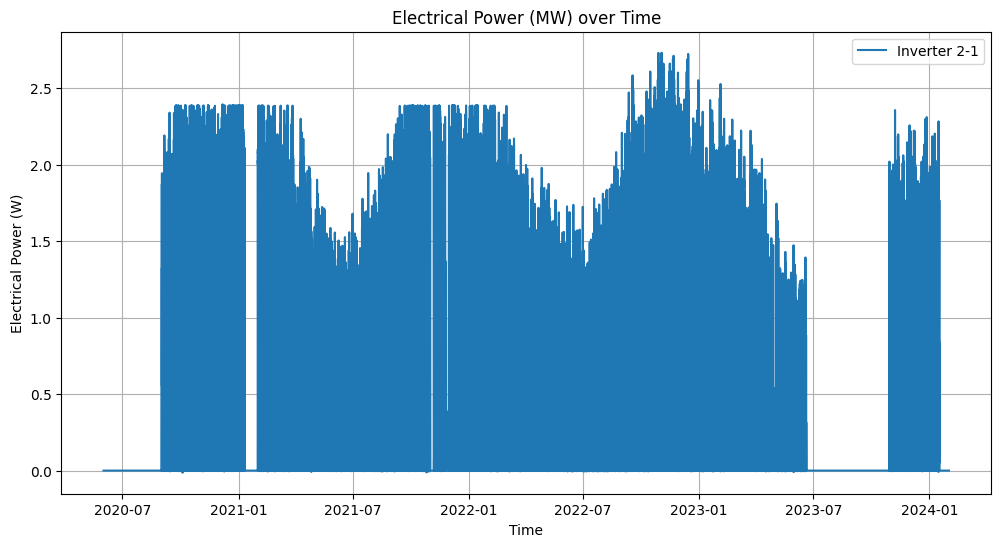

In [2]:
# Load the data from the pickle file
data_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\full_inv_pow_5min.pkl"
df = pd.read_pickle(data_file)

# print the head
print(df.head())

# Set the Timestamp as datatime format and index
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

# scale all values to MW from kW
df = df / 1000.0

# only keep the column for the selected inverter
df = df[[inverter]]

# plot the data, it only has one column
plt.figure(figsize=long_hoz_figsize)
plt.plot(df.index, df[inverter], label=f'Inverter {inverter}')
plt.legend()
plt.title('Electrical Power (MW) over Time')
plt.xlabel('Time')
plt.ylabel('Electrical Power (W)')
plt.grid()
plt.show()


# 3. Simulation results visualisation

## 3.1. Data loading

In [3]:

print(f"Loading SunSolve Yield CSV file: {sunsolve_file}")

try:
    # Load SunSolve CSV with simple read_csv (no special parsing needed)
    simulation_results_df = pd.read_csv(sunsolve_file)
    
    print(f"Raw DataFrame loaded with shape: {simulation_results_df.shape}")
    print(f"Columns: {list(simulation_results_df.columns[:10])}... (showing first 10)")
    
    # Construct timestamp from 'Day of year', 'Hour', 'Minute' columns
    year = 2021
    base_date = pd.Timestamp(f"{year}-01-01")
    
    print("\nConstructing timestamps from Day of year, Hour, Minute columns...")
    simulation_results_df['timestamp'] = simulation_results_df.apply(
        lambda row: base_date + pd.Timedelta(days=int(row['Day of year'])-1) + 
                    pd.Timedelta(hours=int(row['Hour'])) + 
                    pd.Timedelta(minutes=int(row['Minute'])),
        axis=1
    )
    
    # Convert power from W to MW
    print("Converting power from W to MW...")
    if 'Power [unit-system] (W)' in simulation_results_df.columns:
        simulation_results_df['Power_MW'] = simulation_results_df['Power [unit-system] (W)'] / 1e6
    else:
        raise KeyError("Column 'Power [unit-system] (W)' not found in SunSolve data")
    
    # Sort by timestamp to ensure chronological order
    simulation_results_df = simulation_results_df.sort_values('timestamp').reset_index(drop=True)
    
    # Remove duplicate timestamps if any
    duplicates = simulation_results_df.duplicated(subset=['timestamp']).sum()
    if duplicates > 0:
        print(f"Found and removing {duplicates} duplicate timestamps")
        simulation_results_df = simulation_results_df.drop_duplicates(subset=['timestamp'], keep='first')
    
    # Data validation and timestamp analysis
    print("\n=== TIMESTAMP ANALYSIS ===")
    print(f"Total timestamps: {len(simulation_results_df)}")
    print(f"Date range: {simulation_results_df['timestamp'].min()} to {simulation_results_df['timestamp'].max()}")
    
    # Check timestamp continuity
    time_diffs = simulation_results_df['timestamp'].diff()[1:]  # Skip first NaT
    common_diff = time_diffs.value_counts().index[0]
    print(f"Most common time difference: {common_diff}")
    
    irregular_intervals = (time_diffs != common_diff).sum()
    if irregular_intervals > 0:
        print(f"Warning: Found {irregular_intervals} irregular time intervals")
    
    # Check distribution of timestamps by month
    month_counts = simulation_results_df['timestamp'].dt.month.value_counts().sort_index()
    print("\nTimestamps per month:")
    for month, count in month_counts.items():
        print(f"Month {month}: {count} timestamps")
    
    # Print available columns
    print("\nAvailable columns:")
    print(simulation_results_df.columns.tolist()[:20], "... (showing first 20)")
    
    # Check for Power_MW column
    print(f"\nDoes 'Power_MW' column exist? {'Power_MW' in simulation_results_df.columns}")
    if 'Power_MW' in simulation_results_df.columns:
        print(f"Power_MW statistics:\n{simulation_results_df['Power_MW'].describe()}")
        
except Exception as e:
    print(f"Error loading SunSolve Yield CSV: {e}")
    raise


Loading SunSolve Yield CSV file: C:\Users\z5183876\Downloads\Simulation 1 (107) - time series.csv
Raw DataFrame loaded with shape: (8736, 44)
Columns: ['Day of year', 'Hour', 'Minute', 'Period (h)', 'Flag', 'Message', 'Solar zenith (degrees)', 'Solar elevation (degrees)', 'Solar azimuth (degrees)', 'GHI (W/m2)']... (showing first 10)

Constructing timestamps from Day of year, Hour, Minute columns...
Converting power from W to MW...

=== TIMESTAMP ANALYSIS ===
Total timestamps: 8736
Date range: 2021-01-01 00:00:00 to 2021-12-30 23:00:00
Most common time difference: 0 days 01:00:00

Timestamps per month:
Month 1: 744 timestamps
Month 2: 672 timestamps
Month 3: 744 timestamps
Month 4: 720 timestamps
Month 5: 744 timestamps
Month 6: 720 timestamps
Month 7: 744 timestamps
Month 8: 744 timestamps
Month 9: 720 timestamps
Month 10: 744 timestamps
Month 11: 720 timestamps
Month 12: 720 timestamps

Available columns:
['Day of year', 'Hour', 'Minute', 'Period (h)', 'Flag', 'Message', 'Solar zenit

## 3.2. Visualisation

### 3.2.1. Hourly raw data

EArray column is already numeric type: float64
Set timestamp as index
No clipping applied to EArray values
Resampled actual power from 385920 5-minute intervals to 32160 hourly averages


C:\Users\z5183876\AppData\Local\Temp\ipykernel_31664\3093163612.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_actual_power = df[inverter].resample('H').mean()


EArray Min: 0.00 MW
EArray Max: 0.01 MW
EArray Mean: 0.00 MW
Total simulation data points: 8736

Actual Power Min: -0.00 MW
Actual Power Max: 2.27 MW
Actual Power Mean: 0.39 MW
Total actual data points: 32160


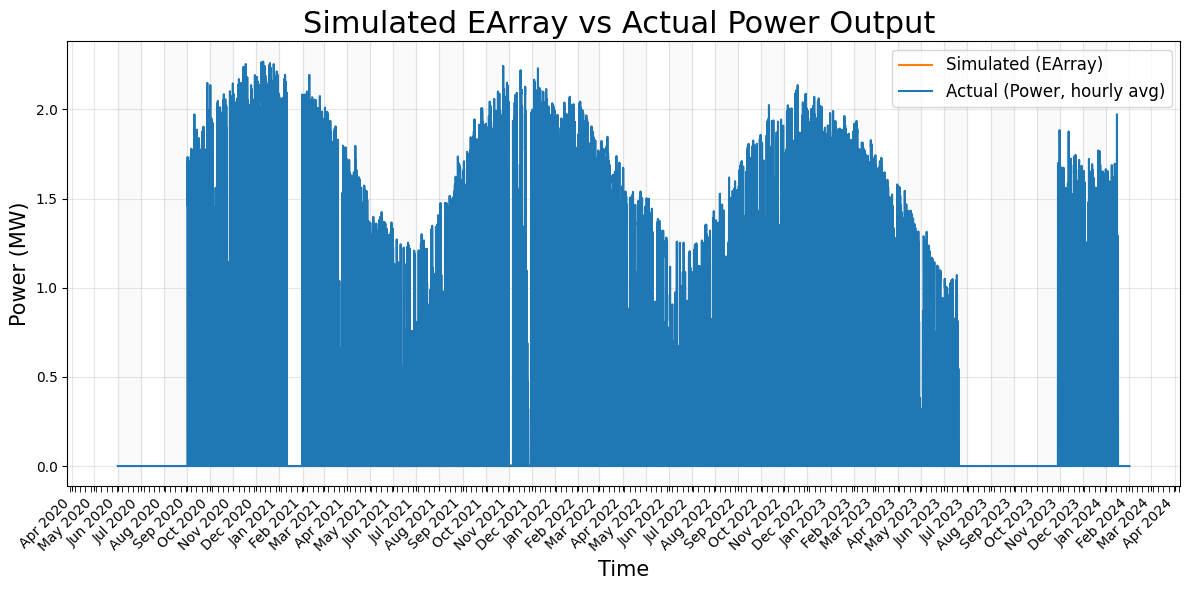

In [4]:
# %matplotlib ipympl
# Define clipping options at the beginning
apply_clipping = False  # Set to False to disable clipping
clipping_threshold = 100  # Clipping threshold in MW

# First check if EArray needs conversion (avoid error if already numeric)
if pd.api.types.is_object_dtype(simulation_results_df['Power_MW']):
    # Only convert if it's still a string/object type
    simulation_results_df['Power_MW'] = pd.to_numeric(
        simulation_results_df['Power_MW'].str.replace(',', '.'), 
        errors='coerce'
    )
    print("Converted EArray column from string to numeric")
else:
    print("EArray column is already numeric type:", simulation_results_df['Power_MW'].dtype)

# Now set the index and sort
if 'timestamp' in simulation_results_df.columns:
    simulation_results_df.set_index('timestamp', inplace=True)
    simulation_results_df.sort_index(inplace=True)
    print("Set timestamp as index")

# Apply clipping to the simulated power if enabled
if apply_clipping:
    simulation_results_df['EArray_display'] = simulation_results_df['Power_MW'].clip(upper=clipping_threshold)
    print(f"Applied {clipping_threshold} MW clipping to EArray values: {(simulation_results_df['Power_MW'] > clipping_threshold).sum()} values clipped")
    earray_label = f'Simulated (EArray, clipped at {clipping_threshold} MW)'
else:
    simulation_results_df['EArray_display'] = simulation_results_df['Power_MW']
    print("No clipping applied to EArray values")
    earray_label = 'Simulated (EArray)'

# Resample the actual power data to hourly averages
hourly_actual_power = df[inverter].resample('H').mean()
# hourly_actual_power = df[inverter].resample('H').first()
print(f"Resampled actual power from {len(df)} 5-minute intervals to {len(hourly_actual_power)} hourly averages")

# Create a figure for both datasets
fig = plt.figure(figsize=long_hoz_figsize)
ax = fig.add_subplot(111)

# Plot simulation EArray data (with or without clipping)
ax.plot(simulation_results_df.index, simulation_results_df['EArray_display'], 
       linewidth=1.5, color='#ff7f0e', label=earray_label)

# Plot actual power data (hourly resampled)
ax.plot(hourly_actual_power.index, hourly_actual_power, 
       linewidth=1.5, color='#1f77b4', label='Actual (Power, hourly avg)')

# Add labels and title
ax.set_xlabel('Time', fontsize=axis_label_size)
ax.set_ylabel('Power (MW)', fontsize=axis_label_size)
title_suffix = " (clipped)" if apply_clipping else ""
ax.set_title(f'Simulated EArray vs Actual Power Output {title_suffix}', fontsize=title_size)

# Add legend
ax.legend(fontsize=text_size)

# Add grid
ax.grid(True, alpha=0.3)

# Enhanced date formatting on x-axis
# Use major ticks for months
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Add minor ticks for days (every 7 days)
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=7))
ax.tick_params(which='minor', length=4, color='k')

# Make sure all dates are visible
fig.autofmt_xdate(rotation=45)

# Increase bottom margin to accommodate date labels
plt.subplots_adjust(bottom=0.2)

# Add a colorized background to differentiate months
first_date = min(simulation_results_df.index.min(), hourly_actual_power.index.min())
last_date = max(simulation_results_df.index.max(), hourly_actual_power.index.max())
months = pd.date_range(start=first_date, end=last_date, freq='MS')


for i, month_start in enumerate(months):
    # Get the last day of the month
    if i < len(months) - 1:
        month_end = months[i + 1]
    else:
        # For the last month, use the last date in our data
        month_end = last_date
    
    # Add a subtle background color alternating between months
    if i % 2 == 0:
        ax.axvspan(month_start, month_end, alpha=0.1, color='lightgray')

# Adjust layout
plt.tight_layout()

# Print some statistics
print(f"EArray Min: {simulation_results_df['EArray_display'].min():.2f} MW")
print(f"EArray Max: {simulation_results_df['EArray_display'].max():.2f} MW")
print(f"EArray Mean: {simulation_results_df['EArray_display'].mean():.2f} MW")
print(f"Total simulation data points: {len(simulation_results_df)}")

print(f"\nActual Power Min: {hourly_actual_power.min():.2f} MW")
print(f"Actual Power Max: {hourly_actual_power.max():.2f} MW")
print(f"Actual Power Mean: {hourly_actual_power.mean():.2f} MW")
print(f"Total actual data points: {len(hourly_actual_power)}")

# Show plot
plt.show()

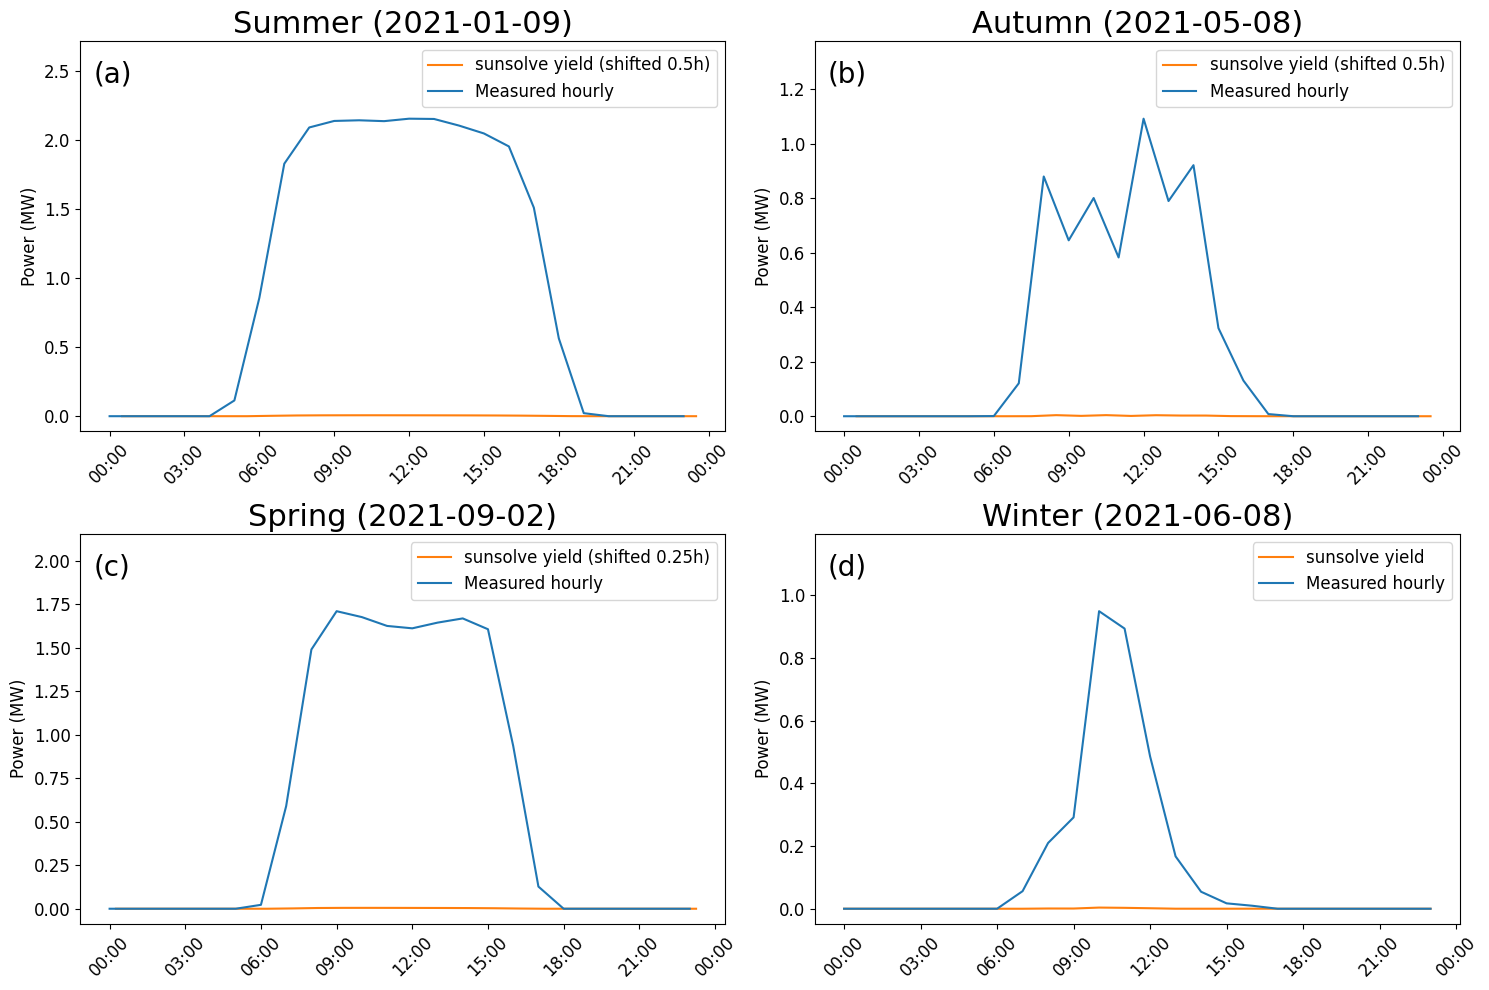

In [5]:
def plot_four_days(dates, time_shifts=None):
    """
    Create a 2x2 subplot grid showing actual vs simulated power for 4 specific days
    
    Parameters:
    -----------
    dates : list
        List of 4 dates as strings in format 'YYYY-MM-DD'
    time_shifts : list, optional
        List of time shifts in hours to apply to each simulated day. 
        Positive values shift data forward in time (later), negative values shift backward (earlier).
        Default is None (no shifts).
    """
    # Convert date strings to datetime objects
    dates = [pd.to_datetime(date) for date in dates]
    
    # If no time shifts provided, default to no shift (0) for each date
    if time_shifts is None:
        time_shifts = [0, 0, 0, 0]
    
    # Create 2x2 subplot grid
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.flatten()  # Flatten to make indexing easier
    labels = ['a', 'b', 'c', 'd']  # Labels for subplots
    
    # Function to get season in Australia
    def get_season(date):
        """Returns the season in Australia based on the date."""
        month = date.month
        day = date.day
        if (month == 12 and day >= 1) or month in [1, 2] or (month == 3 and day < 1):
            return "Summer"
        elif month in [3, 4, 5]:
            return "Autumn"
        elif month in [6, 7, 8]:
            return "Winter"
        else:  # month in [9, 10, 11]
            return "Spring"
    
    # Suppress FutureWarning about 'H' vs 'h'
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    # Loop through each date and create a subplot
    for i, (date, time_shift) in enumerate(zip(dates, time_shifts)):
        # Get just the data for this specific day
        day_start = date.replace(hour=0, minute=0, second=0)
        day_end = date.replace(hour=23, minute=59, second=59)
        
        # Filter actual data (resample to hourly for fair comparison)
        actual_day = df[inverter].loc[day_start:day_end].resample('h').mean()
        
        # Get simulation data directly
        sim_day = simulation_results_df['Power_MW'].loc[day_start:day_end]
        
        # Apply time shift to simulation data if specified
        if time_shift != 0:
            # Create a copy with shifted index
            sim_day_shifted = sim_day.copy()
            sim_day_shifted.index = sim_day.index + pd.Timedelta(hours=time_shift)
            
            # Filter to keep only data points within the same day
            sim_day = sim_day_shifted[
                (sim_day_shifted.index >= day_start) & 
                (sim_day_shifted.index <= day_end)
            ]
        
        # Select the current axis for plotting
        ax = axs[i]
        
        # Plot simulation data
        ax.plot(sim_day.index, sim_day.values, linewidth=1.5, color='#ff7f0e', 
                label=f'sunsolve yield{" (shifted " + str(time_shift) + "h)" if time_shift != 0 else ""}')
        
        # Plot actual power data
        ax.plot(actual_day.index, actual_day.values, linewidth=1.5, color='#1f77b4', label='Measured hourly')
        
        # Get season for the date
        season = get_season(date)
        
        # Set title and labels with date included
        title_text = f"{season} ({date.strftime('%Y-%m-%d')})"
        ax.set_title(title_text, fontsize=title_size)
        
        ax.set_ylabel('Power (MW)', fontsize=text_size)
        
        # Add subplot label
        ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes, fontsize=20, verticalalignment='top')
        
        # Format x-axis to show hours:minutes with date
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', rotation=45, labelsize=text_size)
        ax.tick_params(axis='y', labelsize=text_size)
        
        # Add legend in upper right
        ax.legend(loc='upper right', fontsize=text_size)
        
        # Increase y-limit to add more space at the top for the legend
        current_ylim = ax.get_ylim()
        ax.set_ylim(current_ylim[0], current_ylim[1] * 1.2)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axs

# Example usage with time shifts
dates_to_plot = [
    '2021-01-09',  # Spring
    '2021-05-08',  # Summer
    '2021-09-02',  # Autumn
    '2021-06-08'   # Winter
]

# Define time shifts in hours for each day (can be integer or float)
time_shifts = [0.5, 0.5, 0.25, 0]  # Positive shifts data later, negative shifts earlier

# Call the function with time shifts
fig, axes = plot_four_days(dates_to_plot, time_shifts)

### 3.2.2. Hourly filtered & scaled

EArray column is already numeric type: float64
Applied 2.392 MW clipping to power values: 0 values clipped
Maximum power reduced from 0.01 MW to 0.01 MW
Selected first value of each hour from 385920 5-minute intervals to get 32160 hourly points
Working with hourly data - 32160 actual data points and 8736 simulation data points

=== DATA FILTERING FOR METRICS CALCULATION ===
Step 1: Creating filtered dataframe for metrics
After filtering for matching timestamps: 8736 data points (removed 23424 NaN values)
Zero filtering step removed - keeping all data points including zeros

Step 2: Loading and applying maintenance-free days filter
Loaded 233 maintenance-free days
After filtering for maintenance-free days: 5592 data points (removed 3144 points)

Filtered data date range: 2021-01-01 00:00:00 to 2021-12-30 23:00:00
Number of unique days in filtered data: 233

=== SCALING FACTOR OPTIMIZATION ===
Target MBE tolerance: 1.00e-13

Starting binary search for optimal scaling factor...
Initial se

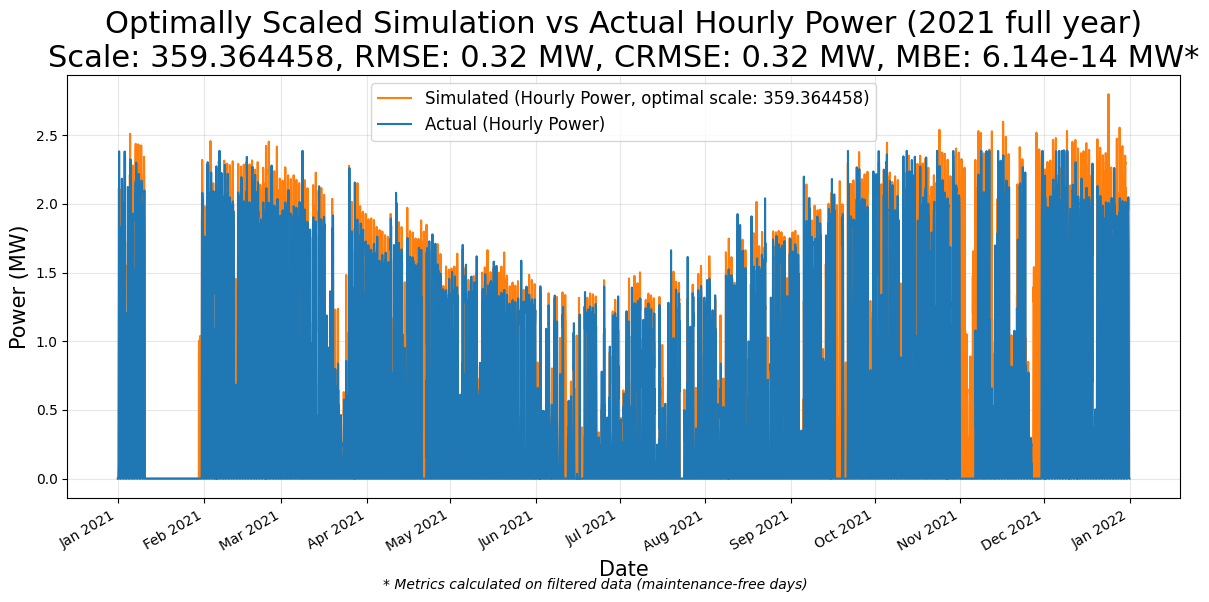


=== STATISTICS WITH OPTIMAL SCALING (2021 DATA) ===
2021 simulation data points: 8736
2021 actual data points: 8760
Scaled Power Min: 0.00 MW
Scaled Power Max: 2.80 MW
Scaled Power Mean: 0.47 MW
Actual Power Min: -0.00 MW
Actual Power Max: 2.39 MW
Actual Power Mean: 0.45 MW

=== FILTERED 2021 DATA FOR PLOTTING ===
Total days in filtered 2021 data: 5592
Mean difference: 6.144917669601264e-14
Median difference: 0.0
The difference is sunsolve yield - Measured


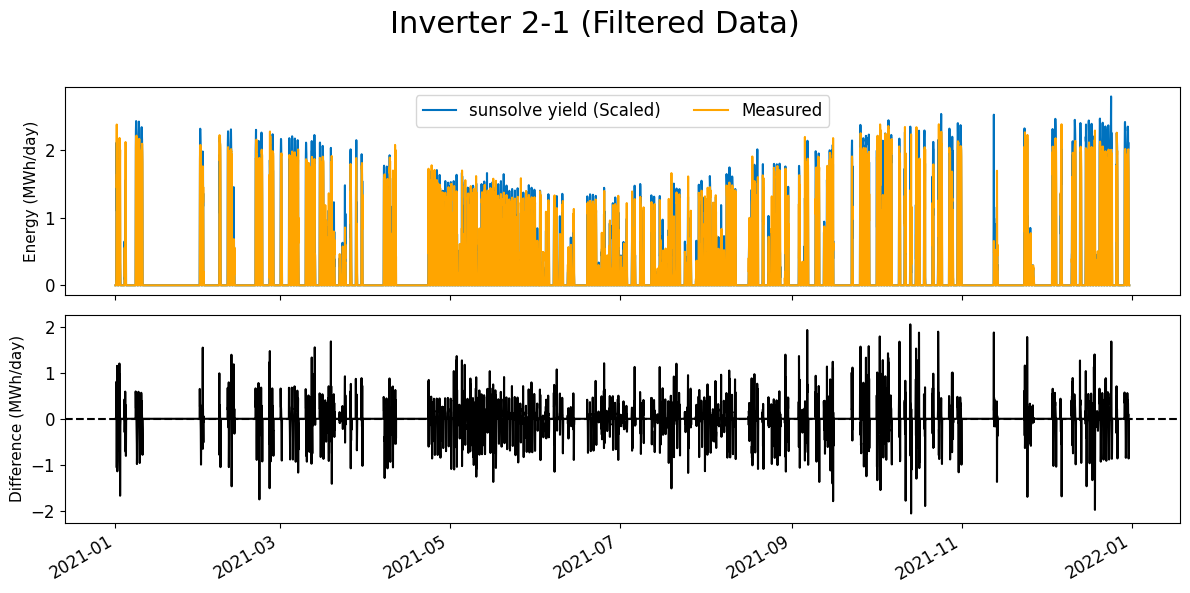


Evaluation Metrics for Inverter 2-1 (FILTERED DATA):
Optimal scaling factor: 359.364458
MBE   : 0.000 MWh/day
MAE   : 0.148 MWh/day
RMSE  : 0.316 MWh/day
CRMSE : 0.316 MWh/day
CMAE  : 0.148 MWh/day
nRMSE : 13.210% (range)
NMAE  : 6.193% (range)
MAPE  : inf%


In [6]:
# Define options at the beginning
apply_clipping = True  # Set to False to disable clipping
clipping_threshold = 2.392 # MW - power clipping threshold 
target_mbe_tolerance = 1e-13  # Target absolute MBE to achieve

# First check if EArray needs conversion (avoid error if already numeric)
if pd.api.types.is_object_dtype(simulation_results_df['Power_MW']):
    # Only convert if it's still a string/object type
    simulation_results_df['Power_MW'] = pd.to_numeric(
        simulation_results_df['Power_MW'].str.replace(',', '.'), 
        errors='coerce'
    )
    print("Converted EArray column from string to numeric")
else:
    print("EArray column is already numeric type:", simulation_results_df['Power_MW'].dtype)

# Apply clipping to raw power values
if apply_clipping:
    original_max = simulation_results_df['Power_MW'].max()
    clipped_count = (simulation_results_df['Power_MW'] > clipping_threshold).sum()
    simulation_results_df['Power_MW'] = simulation_results_df['Power_MW'].clip(upper=clipping_threshold)
    print(f"Applied {clipping_threshold} MW clipping to power values: {clipped_count} values clipped")
    print(f"Maximum power reduced from {original_max:.2f} MW to {simulation_results_df['Power_MW'].max():.2f} MW")

# Now set the index and sort
if 'timestamp' in simulation_results_df.columns:
    simulation_results_df.set_index('timestamp', inplace=True)
    simulation_results_df.sort_index(inplace=True)
    print("Set timestamp as index")

# Resample the actual power data to hourly averages to match simulation data frequency
hourly_actual_power = df[inverter].resample('H').first()  # Using first value instead of mean
print(f"Selected first value of each hour from {len(df)} 5-minute intervals to get {len(hourly_actual_power)} hourly points")

# No resampling to daily - keeping hourly resolution
print(f"Working with hourly data - {len(hourly_actual_power)} actual data points and {len(simulation_results_df)} simulation data points")

# Create a combined dataframe with both actual and simulated power for metrics calculation
print("\n=== DATA FILTERING FOR METRICS CALCULATION ===")
print("Step 1: Creating filtered dataframe for metrics")
metrics_df = pd.DataFrame()
metrics_df['Actual'] = hourly_actual_power
metrics_df['Simulated'] = simulation_results_df['Power_MW']

# Filter to include only timestamps where both actual and simulated power exist
initial_rows = len(metrics_df)
metrics_df = metrics_df.dropna()
print(f"After filtering for matching timestamps: {len(metrics_df)} data points (removed {initial_rows - len(metrics_df)} NaN values)")

# Keeping all values including zeros
print("Zero filtering step removed - keeping all data points including zeros")

# Load the maintenance-free days from the text file
print("\nStep 2: Loading and applying maintenance-free days filter")
maintenance_free_days_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\remaining_dates_2021.txt"
try:
    with open(maintenance_free_days_file, 'r') as f:
        maintenance_free_days = [line.strip() for line in f.readlines() if line.strip()]
    
    print(f"Loaded {len(maintenance_free_days)} maintenance-free days")
    
    # Convert maintenance-free days to datetime for filtering
    maintenance_free_dates = pd.to_datetime(maintenance_free_days)
    
    # Filter the metrics dataframe to only include maintenance-free days
    metrics_df['date'] = metrics_df.index.date
    initial_rows = len(metrics_df)
    metrics_df = metrics_df[metrics_df['date'].isin([date.date() for date in maintenance_free_dates])]
    
    print(f"After filtering for maintenance-free days: {len(metrics_df)} data points (removed {initial_rows - len(metrics_df)} points)")
    
except Exception as e:
    print(f"Error loading maintenance-free days: {e}")
    print("Continuing with only the non-NaN data points")

# Print the date range of the filtered data
if len(metrics_df) > 0:
    print(f"\nFiltered data date range: {metrics_df.index.min()} to {metrics_df.index.max()}")
    print(f"Number of unique days in filtered data: {len(metrics_df['date'].unique())}")
else:
    print("\nWarning: No data points remain after filtering!")
    print("Please check your maintenance-free days file and data availability.")

# Check if we have enough data to proceed
if len(metrics_df) < 10:
    print("\nWARNING: Very few data points remain after filtering!")
    print("Results may not be statistically significant.")

# Function to calculate MBE for a given scale factor (uses filtered data)
def calculate_mbe(scale_factor, apply_clip=False, clip_threshold=2.392):
    """Calculate Mean Bias Error for given scale factor"""
    # Scale the simulated data (clipping already applied at power level)
    scaled_data = metrics_df['Simulated'] * scale_factor
    
    # Calculate MBE
    return np.mean(scaled_data - metrics_df['Actual'])

print("\n=== SCALING FACTOR OPTIMIZATION ===")
print(f"Target MBE tolerance: {target_mbe_tolerance:.2e}")

# Binary search to find optimal scaling factor
def find_optimal_scaling_factor(min_factor=0.5, max_factor=2.0, max_iterations=100):
    print("\nStarting binary search for optimal scaling factor...")
    print(f"Initial search range: [{min_factor:.8f}, {max_factor:.8f}]")
    
    iterations = 0
    best_factor = None
    best_mbe = float('inf')
    
    while iterations < max_iterations:
        iterations += 1
        mid_factor = (min_factor + max_factor) / 2
        
        # Calculate MBE for the current factor
        mbe = calculate_mbe(mid_factor, apply_clipping, clipping_threshold)
        
        # Track the best factor found
        if abs(mbe) < abs(best_mbe):
            best_factor = mid_factor
            best_mbe = mbe
        
        print(f"Iteration {iterations}: Factor = {mid_factor:.10f}, MBE = {mbe:.10e}")
        
        # Check if we've reached the target precision
        if abs(mbe) < target_mbe_tolerance:
            print(f"✓ Converged! Found factor with MBE below tolerance.")
            return mid_factor, mbe, iterations
        
        # Adjust search range based on MBE sign
        if mbe > 0:  # MBE is positive, need to decrease factor
            max_factor = mid_factor
        else:  # MBE is negative, need to increase factor
            min_factor = mid_factor
        
        # Check if search range is too small (reached numerical precision limit)
        if max_factor - min_factor < 1e-15:
            print(f"! Reached numerical precision limit after {iterations} iterations.")
            print(f"  Best MBE achieved: {best_mbe:.12e}")
            return best_factor, best_mbe, iterations
    
    print(f"! Reached maximum iterations ({max_iterations}).")
    print(f"  Best MBE achieved: {best_mbe:.12e}")
    return best_factor, best_mbe, iterations


def find_optimal_scaling_factor(min_factor=0.5, max_factor=1e10, max_iterations=100):
    """
    Find optimal scaling factor using binary search to minimize MBE.
    
    Physical interpretation:
    - Positive MBE: Simulated values too high → decrease scale factor
    - Negative MBE: Simulated values too low → increase scale factor
    """
    print("\nStarting binary search for optimal scaling factor...")
    print(f"Initial search range: [{min_factor:.8f}, {max_factor:.8f}]")
    
    iterations = 0
    best_factor = None
    best_mbe = float('inf')
    
    while iterations < max_iterations:
        iterations += 1
        mid_factor = (min_factor + max_factor) / 2
        
        # Calculate MBE for the current factor
        mbe = calculate_mbe(mid_factor, apply_clipping, clipping_threshold)
        
        # Track the best factor found
        if abs(mbe) < abs(best_mbe):
            best_factor = mid_factor
            best_mbe = mbe
        
        if iterations % 10 == 0 or iterations < 10:
            print(f"Iteration {iterations}: Factor = {mid_factor:.10f}, MBE = {mbe:.10e}")
        
        # Check if we've reached the target precision
        if abs(mbe) < target_mbe_tolerance:
            print(f"✓ Converged! Found factor with MBE below tolerance.")
            return mid_factor, mbe, iterations
        
        # CORRECTED LOGIC:
        # If MBE is positive: simulated > actual → need to DECREASE factor
        # If MBE is negative: simulated < actual → need to INCREASE factor
        if mbe > 0:
            max_factor = mid_factor  # Simulated too high, reduce upper bound
        else:
            min_factor = mid_factor  # Simulated too low, increase lower bound
        
        # Check if search range is too small (reached numerical precision limit)
        if max_factor - min_factor < 1e-15:
            print(f"! Reached numerical precision limit after {iterations} iterations.")
            print(f"  Best MBE achieved: {best_mbe:.12e}")
            return best_factor, best_mbe, iterations
    
    print(f"! Reached maximum iterations ({max_iterations}).")
    print(f"  Best MBE achieved: {best_mbe:.12e}")
    return best_factor, best_mbe, iterations
# Only proceed with optimization if we have data
if len(metrics_df) > 0:
    # Find the optimal scaling factor using filtered data
    optimal_factor, final_mbe, iterations = find_optimal_scaling_factor()

    print("\n=== OPTIMIZATION RESULTS ===")
    print(f"Optimal scaling factor: {optimal_factor:.10f}")
    print(f"Final MBE: {final_mbe:.12e} MW")  # Changed from MWh/day to MW
    print(f"Found in {iterations} iterations")

    # Apply the optimal scaling factor to the filtered data for metrics
    sunsolve_yield_scaling = optimal_factor
    print(f"\nApplying optimal scale factor {sunsolve_yield_scaling:.10f} to sunsolve yield data...")

    # Apply scale factor to filtered data (clipping already applied at power level)
    metrics_df['Simulated_scaled'] = metrics_df['Simulated'] * sunsolve_yield_scaling

    # No need to apply clipping again since it was done at the power level
    metrics_df['Simulated_display'] = metrics_df['Simulated_scaled']

    # Calculate error metrics with optimal scaling (using filtered data)
    # 1. RMSE (Root Mean Square Error)
    rmse = np.sqrt(mean_squared_error(metrics_df['Actual'], metrics_df['Simulated_display']))
    
    # 2. CRMSE (Centralized Root Mean Square Error)
    actual_centered = metrics_df['Actual'] - metrics_df['Actual'].mean()
    simulated_centered = metrics_df['Simulated_display'] - metrics_df['Simulated_display'].mean()
    crmse = np.sqrt(np.mean((actual_centered - simulated_centered)**2))
    
    # 3. MBE (Mean Bias Error) - should be very close to zero
    mbe = np.mean(metrics_df['Simulated_display'] - metrics_df['Actual'])
    
    print("\n=== ERROR METRICS WITH OPTIMAL SCALING (ON FILTERED DATA) ===")
    print(f"RMSE: {rmse:.4f} MW")  # Changed from MWh/day to MW
    print(f"CRMSE: {crmse:.4f} MW")  # Changed from MWh/day to MW
    print(f"MBE: {mbe:.12e} MW")  # Changed from MWh/day to MW
    # calculate the normalised RMSE as a percentage of the range of actual values
    nrmse = rmse / (metrics_df['Actual'].max() - metrics_df['Actual'].min())
    print(f"nRMSE: {nrmse:.4%} of actual range")
    
    # Verify if target was met
    if abs(mbe) < target_mbe_tolerance:
        print(f"✓ SUCCESS: |MBE| = {abs(mbe):.12e} < {target_mbe_tolerance:.2e}")
    else:
        print(f"! WARNING: |MBE| = {abs(mbe):.12e} > {target_mbe_tolerance:.2e}")
        print("  Target tolerance not achieved exactly due to numerical precision limits.")

    # Create a figure showing optimized results for 2021 data only
    plt.figure(figsize=long_hoz_figsize)
    
    # Apply the same scaling factor to all simulation data for plotting
    all_simulation_scaled = simulation_results_df['Power_MW'] * sunsolve_yield_scaling
    
    # Filter for 2021 data only
    year_2021_simulated = all_simulation_scaled[all_simulation_scaled.index.year == 2021]
    year_2021_actual = hourly_actual_power[hourly_actual_power.index.year == 2021]
    
    print(f"\n=== 2021 DATA FILTERING ===")
    print(f"Total hours in 2021 with simulation data: {len(year_2021_simulated)}")
    print(f"Total hours in 2021 with actual data: {len(year_2021_actual)}")

    # Plot 2021 scaled simulation data
    plt.plot(year_2021_simulated.index, year_2021_simulated, 
             linewidth=1.5, color='#ff7f0e', label=f'Simulated (Hourly Power, optimal scale: {sunsolve_yield_scaling:.6f})')

    # Plot 2021 actual power data
    plt.plot(year_2021_actual.index, year_2021_actual, 
             linewidth=1.5, color='#1f77b4', label='Actual (Hourly Power)')

    # Add labels and title
    plt.xlabel('Date', fontsize=axis_label_size)
    plt.ylabel('Power (MW)', fontsize=axis_label_size)  # Changed from Energy to Power

    # Add metrics to title (but note these are from filtered data)
    plt.title(f'Optimally Scaled Simulation vs Actual Hourly Power (2021 full year)\n'
              f'Scale: {optimal_factor:.6f}, RMSE: {rmse:.2f} MW, CRMSE: {crmse:.2f} MW, MBE: {mbe:.2e} MW*', 
              fontsize=title_size)
    
    # Add a note about metrics
    plt.figtext(0.5, 0.01, 
                '* Metrics calculated on filtered data (maintenance-free days)',
                ha='center', fontsize=10, style='italic')

    # Add legend and formatting
    plt.legend(fontsize=text_size)
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gcf().autofmt_xdate()
    plt.tight_layout()

    # Show plot
    plt.show()

    # Print statistics for 2021 data
    print(f"\n=== STATISTICS WITH OPTIMAL SCALING (2021 DATA) ===")
    print(f"2021 simulation data points: {len(year_2021_simulated)}")
    print(f"2021 actual data points: {len(year_2021_actual)}")
    print(f"Scaled Power Min: {year_2021_simulated.min():.2f} MW")
    print(f"Scaled Power Max: {year_2021_simulated.max():.2f} MW")
    print(f"Scaled Power Mean: {year_2021_simulated.mean():.2f} MW")
    print(f"Actual Power Min: {year_2021_actual.min():.2f} MW")
    print(f"Actual Power Max: {year_2021_actual.max():.2f} MW")
    print(f"Actual Power Mean: {year_2021_actual.mean():.2f} MW")
else:
    print("\nERROR: No data points remain after filtering. Cannot proceed with optimization.")
    print("Please check your maintenance-free days file and data availability.")


# Create a two-panel figure showing FILTERED 2021 data (instead of all data)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=long_hoz_figsize, sharex=True,
                              gridspec_kw={'height_ratios':[1,1]})

# Add a proper title at the top of the figure with inverter information
fig.suptitle(f'Inverter {inverter} (Filtered Data)', 
             fontsize=title_size, y=0.98)

# Make sure we're using the properly filtered data
filtered_2021_metrics = metrics_df[metrics_df.index.year == 2021].copy()
print(f"\n=== FILTERED 2021 DATA FOR PLOTTING ===")
print(f"Total days in filtered 2021 data: {len(filtered_2021_metrics)}")

if len(filtered_2021_metrics) > 0:
    # Plot the simulated data (filtered, scaled)
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Simulated_display'], 
             label='sunsolve yield (Scaled)', color='#0072BF')
    
    # Plot the filtered actual data
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Actual'], 
             label='Measured', color='orange')
    
    # Add labels and formatting for top panel
    ax1.set_ylabel('Energy (MWh/day)', fontsize=axis_label_size-4)
    ax1.legend(fontsize=text_size, loc='upper center', ncol=2)
    ax1.tick_params(labelsize=axis_num_size)
    
    # Calculate residuals (Simulated - Actual)
    residuals = filtered_2021_metrics['Simulated_display'] - filtered_2021_metrics['Actual']
    print("Mean difference:", residuals.mean())
    print("Median difference:", residuals.median())
    print('The difference is sunsolve yield - Measured')
    
    # Plot residuals in bottom panel
    ax2.plot(residuals.index, residuals, color='black', label='Difference')
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_ylabel('Difference (MWh/day)', fontsize=axis_label_size-4)
    ax2.tick_params(labelsize=axis_num_size)
    
    # Add x-axis formatting
    plt.gcf().autofmt_xdate()
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate the suptitle
    
    # Show plot
    plt.show()
    
    # Calculate metrics on filtered data
    mbe = residuals.mean()
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    crmse = np.sqrt(np.mean((residuals - mbe)**2))
    cmae = np.mean(np.abs(residuals - mbe))
    
    meas_range = filtered_2021_metrics['Actual'].max() - filtered_2021_metrics['Actual'].min()
    nrmse = rmse / meas_range * 100
    nmae = mae / meas_range * 100
    mape = np.mean(np.abs(residuals / filtered_2021_metrics['Actual'])) * 100
    
    # Print metrics for filtered data
    print(f"\nEvaluation Metrics for Inverter {inverter} (FILTERED DATA):")
    print(f"Optimal scaling factor: {optimal_factor:.6f}")
    print(f"MBE   : {mbe:.3f} MWh/day")
    print(f"MAE   : {mae:.3f} MWh/day")
    print(f"RMSE  : {rmse:.3f} MWh/day")
    print(f"CRMSE : {crmse:.3f} MWh/day")
    print(f"CMAE  : {cmae:.3f} MWh/day")
    print(f"nRMSE : {nrmse:.3f}% (range)")
    print(f"NMAE  : {nmae:.3f}% (range)")
    print(f"MAPE  : {mape:.3f}%")
    
    # Save the filtered comparison plot
    # plot_file_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\sunsolve yield_vs_measured_comparison_filtered.png"
    # fig.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    # print(f"\nFiltered plot saved to: {plot_file_path}")
    
else:
    print("\nERROR: No filtered data points from 2021 remain after filtering.")
    print("Please check your maintenance-free days file and data availability.")

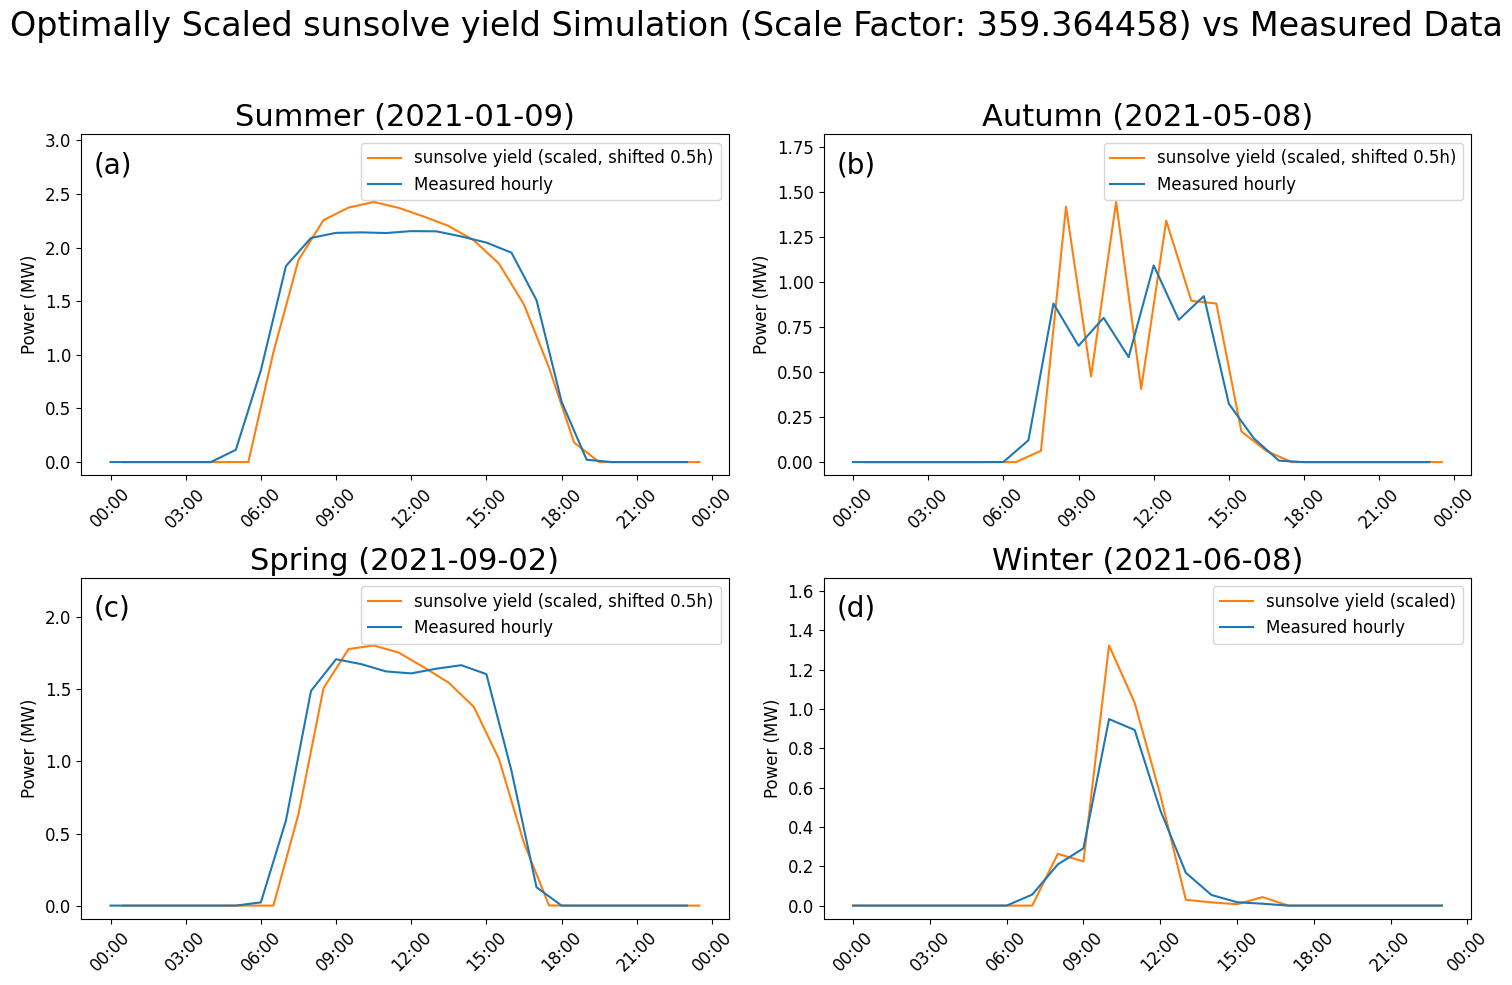

In [7]:
def plot_four_days_scaled(dates, time_shifts=None):
    """
    Create a 2x2 subplot grid showing actual vs optimally scaled simulated power for 4 specific days
    
    Parameters:
    -----------
    dates : list
        List of 4 dates as strings in format 'YYYY-MM-DD'
    time_shifts : list, optional
        List of time shifts in hours to apply to each simulated day. 
        Positive values shift data forward in time (later), negative values shift backward (earlier).
        Default is None (no shifts).
    """
    # Convert date strings to datetime objects
    dates = [pd.to_datetime(date) for date in dates]
    
    # If no time shifts provided, default to no shift (0) for each date
    if time_shifts is None:
        time_shifts = [0, 0, 0, 0]
    
    # Create 2x2 subplot grid
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.flatten()  # Flatten to make indexing easier
    labels = ['a', 'b', 'c', 'd']  # Labels for subplots
    
    # Function to get season in Australia
    def get_season(date):
        """Returns the season in Australia based on the date."""
        month = date.month
        day = date.day
        if (month == 12 and day >= 1) or month in [1, 2] or (month == 3 and day < 1):
            return "Summer"
        elif month in [3, 4, 5]:
            return "Autumn"
        elif month in [6, 7, 8]:
            return "Winter"
        else:  # month in [9, 10, 11]
            return "Spring"
    
    # Suppress FutureWarning about 'H' vs 'h'
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    # Loop through each date and create a subplot
    for i, (date, time_shift) in enumerate(zip(dates, time_shifts)):
        # Get just the data for this specific day
        day_start = date.replace(hour=0, minute=0, second=0)
        day_end = date.replace(hour=23, minute=59, second=59)
        
        # Filter actual data (resample to hourly for fair comparison)
        actual_day = df[inverter].loc[day_start:day_end].resample('h').mean()
        
        # Get simulation data directly and apply optimal scaling factor
        sim_day = simulation_results_df['Power_MW'].loc[day_start:day_end] * sunsolve_yield_scaling
        
        # Apply time shift to simulation data if specified
        if time_shift != 0:
            # Create a copy with shifted index
            sim_day_shifted = sim_day.copy()
            sim_day_shifted.index = sim_day.index + pd.Timedelta(hours=time_shift)
            
            # Filter to keep only data points within the same day
            sim_day = sim_day_shifted[
                (sim_day_shifted.index >= day_start) & 
                (sim_day_shifted.index <= day_end)
            ]
        
        # Select the current axis for plotting
        ax = axs[i]
        
        # Plot scaled simulation data
        ax.plot(sim_day.index, sim_day.values, linewidth=1.5, color='#ff7f0e', 
                label=f'sunsolve yield (scaled{", shifted " + str(time_shift) + "h" if time_shift != 0 else ""})')
        
        # Plot actual power data
        ax.plot(actual_day.index, actual_day.values, linewidth=1.5, color='#1f77b4', label='Measured hourly')
        
        # Get season for the date
        season = get_season(date)
        
        # Set title and labels with date included
        title_text = f"{season} ({date.strftime('%Y-%m-%d')})"
        ax.set_title(title_text, fontsize=title_size)
        
        ax.set_ylabel('Power (MW)', fontsize=text_size)
        
        # Add subplot label
        ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes, fontsize=20, verticalalignment='top')
        
        # Format x-axis to show hours:minutes with date
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', rotation=45, labelsize=text_size)
        ax.tick_params(axis='y', labelsize=text_size)
        
        # Add legend in upper right
        ax.legend(loc='upper right', fontsize=text_size)
        
        # Increase y-limit to add more space at the top for the legend
        current_ylim = ax.get_ylim()
        ax.set_ylim(current_ylim[0], current_ylim[1] * 1.2)
    
    # Add a suptitle with scaling factor info
    plt.suptitle(f'Optimally Scaled sunsolve yield Simulation (Scale Factor: {sunsolve_yield_scaling:.6f}) vs Measured Data', 
                 fontsize=title_size+2, y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
    plt.show()
    
    return fig, axs

# Example usage with time shifts
dates_to_plot = [
    '2021-01-09',  # Summer
    '2021-05-08',  # Autumn
    '2021-09-02',  # Spring
    '2021-06-08'   # Winter
]

# Define time shifts in hours for each day (can be integer or float)
time_shifts = [0.5, 0.5, 0.5, 0]  # Positive shifts data later, negative shifts earlier

# Call the function with time shifts
fig, axes = plot_four_days_scaled(dates_to_plot, time_shifts)

### 3.2.3. Daily filtered & scaled

#### 3.2.3.1. Plot the data before filtering

EArray column is already numeric type: float64
Applied 2.392 MW clipping to power values: 0 values clipped
Maximum power reduced from 0.01 MW to 0.01 MW
Resampled actual power from 385920 5-minute intervals to 1340 daily totals
Resampled simulated power from 8736 hourly values to 364 daily totals

=== DATA FILTERING FOR METRICS CALCULATION ===
Step 1: Creating filtered dataframe for metrics
After filtering for matching dates: 364 data points (removed 976 NaN values)
Zero filtering step removed - keeping all data points including zeros

Step 2: Loading and applying maintenance-free days filter
Loaded 233 maintenance-free days
After filtering for maintenance-free days: 233 data points (removed 131 points)

Filtered data date range: 2021-01-01 00:00:00 to 2021-12-30 00:00:00
Number of unique days in filtered data: 233

=== SCALING FACTOR OPTIMIZATION ===
Target MBE tolerance: 1.00e-13

Starting binary search for optimal scaling factor...
Initial search range: [0.50000000, 20000000000.0000

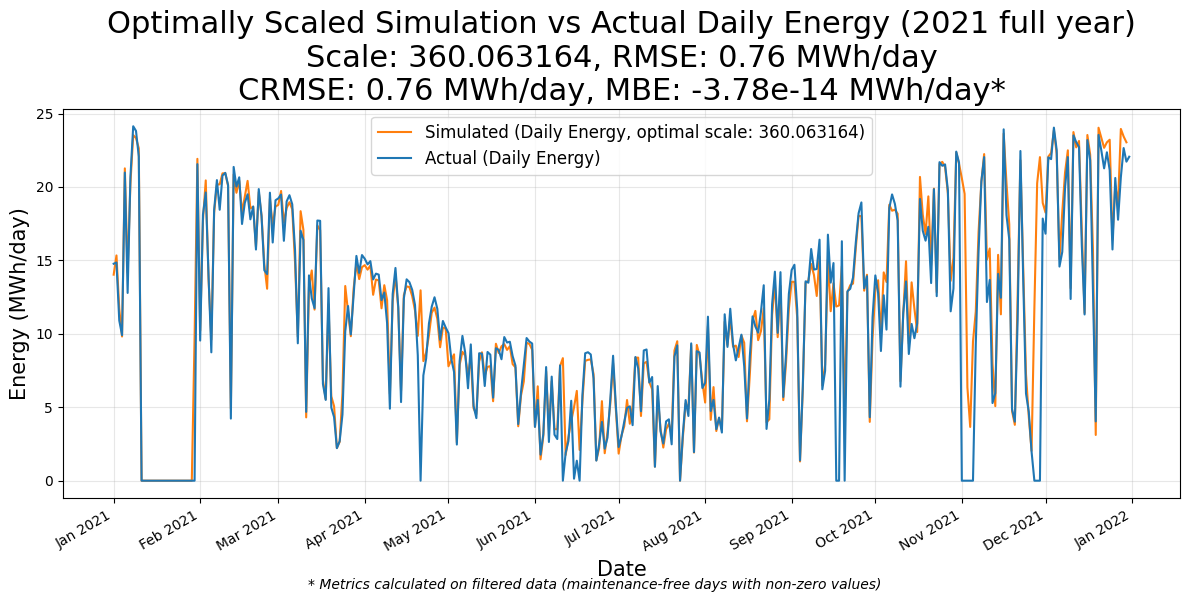


=== STATISTICS WITH OPTIMAL SCALING (2021 DATA) ===
2021 simulation data points: 364
2021 actual data points: 365
Scaled Daily Energy Min: 0.00 MWh/day
Scaled Daily Energy Max: 24.03 MWh/day
Scaled Daily Energy Mean: 11.28 MWh/day
Actual Daily Energy Min: 0.00 MWh/day
Actual Daily Energy Max: 24.13 MWh/day
Actual Daily Energy Mean: 10.71 MWh/day


In [8]:
# Define options at the beginning
apply_clipping = True  # Set to False to disable clipping
clipping_threshold = 2.392 # MW - power clipping threshold 
target_mbe_tolerance = 1e-13  # Target absolute MBE to achieve

# First check if EArray needs conversion (avoid error if already numeric)
if pd.api.types.is_object_dtype(simulation_results_df['Power_MW']):
    # Only convert if it's still a string/object type
    simulation_results_df['Power_MW'] = pd.to_numeric(
        simulation_results_df['Power_MW'].str.replace(',', '.'), 
        errors='coerce'
    )
    print("Converted EArray column from string to numeric")
else:
    print("EArray column is already numeric type:", simulation_results_df['Power_MW'].dtype)

# Apply clipping to raw power values BEFORE energy conversion
if apply_clipping:
    original_max = simulation_results_df['Power_MW'].max()
    clipped_count = (simulation_results_df['Power_MW'] > clipping_threshold).sum()
    simulation_results_df['Power_MW'] = simulation_results_df['Power_MW'].clip(upper=clipping_threshold)
    print(f"Applied {clipping_threshold} MW clipping to power values: {clipped_count} values clipped")
    print(f"Maximum power reduced from {original_max:.2f} MW to {simulation_results_df['Power_MW'].max():.2f} MW")

# Now set the index and sort
if 'timestamp' in simulation_results_df.columns:
    simulation_results_df.set_index('timestamp', inplace=True)
    simulation_results_df.sort_index(inplace=True)
    print("Set timestamp as index")

# Convert Power (MW) to Energy (MWh) for 5-minute data by multiplying by time fraction
df['Energy_MWh'] = df[inverter] * (5/60)  # 5 minutes = 5/60 hours

# Resample actual power data to daily energy totals (MWh/day)
daily_actual_energy = df['Energy_MWh'].resample('D').sum()
print(f"Resampled actual power from {len(df)} 5-minute intervals to {len(daily_actual_energy)} daily totals")

# Convert hourly simulation data (MW) to hourly energy (MWh) and resample to daily
simulation_results_df['EArray_MWh'] = simulation_results_df['Power_MW'] * 1.0  # 1 hour energy
daily_simulated_energy = simulation_results_df['EArray_MWh'].resample('D').sum()
print(f"Resampled simulated power from {len(simulation_results_df)} hourly values to {len(daily_simulated_energy)} daily totals")

# ...existing code...

# Create a combined dataframe with both actual and simulated energy for metrics calculation
print("\n=== DATA FILTERING FOR METRICS CALCULATION ===")
print("Step 1: Creating filtered dataframe for metrics")
metrics_df = pd.DataFrame()
metrics_df['Actual'] = daily_actual_energy
metrics_df['Simulated'] = daily_simulated_energy

# Filter to include only timestamps where both actual and simulated energy exist
initial_rows = len(metrics_df)
metrics_df = metrics_df.dropna()
print(f"After filtering for matching dates: {len(metrics_df)} data points (removed {initial_rows - len(metrics_df)} NaN values)")

# REMOVED: Filter to include only timestamps where both actual and simulated energy are non-zero
# The line below is removed to keep zero values in the dataset
# metrics_df = metrics_df[(metrics_df['Actual'] > 0) & (metrics_df['Simulated'] > 0)]
print("Zero filtering step removed - keeping all data points including zeros")

# Load the maintenance-free days from the text file
print("\nStep 2: Loading and applying maintenance-free days filter")
maintenance_free_days_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\remaining_dates_2021.txt"
try:
    with open(maintenance_free_days_file, 'r') as f:
        maintenance_free_days = [line.strip() for line in f.readlines() if line.strip()]
    
    print(f"Loaded {len(maintenance_free_days)} maintenance-free days")
    
    # Convert maintenance-free days to datetime for filtering
    maintenance_free_dates = pd.to_datetime(maintenance_free_days)
    
    # Filter the metrics dataframe to only include maintenance-free days
    metrics_df['date'] = metrics_df.index.date
    initial_rows = len(metrics_df)
    metrics_df = metrics_df[metrics_df['date'].isin([date.date() for date in maintenance_free_dates])]
    
    print(f"After filtering for maintenance-free days: {len(metrics_df)} data points (removed {initial_rows - len(metrics_df)} points)")
    
except Exception as e:
    print(f"Error loading maintenance-free days: {e}")
    print("Continuing with only the non-NaN data points")

# Print the date range of the filtered data
if len(metrics_df) > 0:
    print(f"\nFiltered data date range: {metrics_df.index.min()} to {metrics_df.index.max()}")
    print(f"Number of unique days in filtered data: {len(metrics_df['date'].unique())}")
else:
    print("\nWarning: No data points remain after filtering!")
    print("Please check your maintenance-free days file and data availability.")

# Check if we have enough data to proceed
if len(metrics_df) < 10:
    print("\nWARNING: Very few data points remain after filtering!")
    print("Results may not be statistically significant.")

# ...rest of the code remains the same...

# Function to calculate MBE for a given scale factor (uses filtered data)
def calculate_mbe(scale_factor, apply_clip=False, clip_threshold=2400):
    """Calculate Mean Bias Error for given scale factor"""
    # Scale the simulated data (clipping already applied at power level)
    scaled_data = metrics_df['Simulated'] * scale_factor
    
    # Calculate MBE
    return np.mean(scaled_data - metrics_df['Actual'])

print("\n=== SCALING FACTOR OPTIMIZATION ===")
print(f"Target MBE tolerance: {target_mbe_tolerance:.2e}")

# Binary search to find optimal scaling factor
def find_optimal_scaling_factor(min_factor=0.5, max_factor=2e10, max_iterations=100):
    print("\nStarting binary search for optimal scaling factor...")
    print(f"Initial search range: [{min_factor:.8f}, {max_factor:.8f}]")
    
    iterations = 0
    best_factor = None
    best_mbe = float('inf')
    
    while iterations < max_iterations:
        iterations += 1
        mid_factor = (min_factor + max_factor) / 2
        
        # Calculate MBE for the current factor
        mbe = calculate_mbe(mid_factor, apply_clipping, clipping_threshold)
        
        # Track the best factor found
        if abs(mbe) < abs(best_mbe):
            best_factor = mid_factor
            best_mbe = mbe
        
        print(f"Iteration {iterations}: Factor = {mid_factor:.10f}, MBE = {mbe:.10e}")
        
        # Check if we've reached the target precision
        if abs(mbe) < target_mbe_tolerance:
            print(f"✓ Converged! Found factor with MBE below tolerance.")
            return mid_factor, mbe, iterations
        
        # Adjust search range based on MBE sign
        if mbe > 0:  # MBE is positive, need to decrease factor
            max_factor = mid_factor
        else:  # MBE is negative, need to increase factor
            min_factor = mid_factor
        
        # Check if search range is too small (reached numerical precision limit)
        if max_factor - min_factor < 1e-15:
            print(f"! Reached numerical precision limit after {iterations} iterations.")
            print(f"  Best MBE achieved: {best_mbe:.12e}")
            return best_factor, best_mbe, iterations
    
    print(f"! Reached maximum iterations ({max_iterations}).")
    print(f"  Best MBE achieved: {best_mbe:.12e}")
    return best_factor, best_mbe, iterations

# Only proceed with optimization if we have data
if len(metrics_df) > 0:
    # Find the optimal scaling factor using filtered data
    optimal_factor, final_mbe, iterations = find_optimal_scaling_factor()

    print("\n=== OPTIMIZATION RESULTS ===")
    print(f"Optimal scaling factor: {optimal_factor:.10f}")
    print(f"Final MBE: {final_mbe:.12e} MWh/day")
    print(f"Found in {iterations} iterations")

    # Apply the optimal scaling factor to the filtered data for metrics
    sunsolve_yield_scaling = optimal_factor
    print(f"\nApplying optimal scale factor {sunsolve_yield_scaling:.10f} to sunsolve yield data...")

    # Apply scale factor to filtered data (clipping already applied at power level)
    metrics_df['Simulated_scaled'] = metrics_df['Simulated'] * sunsolve_yield_scaling

    # No need to apply clipping again since it was done at the power level
    metrics_df['Simulated_display'] = metrics_df['Simulated_scaled']

    # Calculate error metrics with optimal scaling (using filtered data)
    # 1. RMSE (Root Mean Square Error)
    rmse = np.sqrt(mean_squared_error(metrics_df['Actual'], metrics_df['Simulated_display']))
    
    # 2. CRMSE (Centralized Root Mean Square Error)
    actual_centered = metrics_df['Actual'] - metrics_df['Actual'].mean()
    simulated_centered = metrics_df['Simulated_display'] - metrics_df['Simulated_display'].mean()
    crmse = np.sqrt(np.mean((actual_centered - simulated_centered)**2))
    
    # 3. MBE (Mean Bias Error) - should be very close to zero
    mbe = np.mean(metrics_df['Simulated_display'] - metrics_df['Actual'])
    
    print("\n=== ERROR METRICS WITH OPTIMAL SCALING (ON FILTERED DATA) ===")
    print(f"RMSE: {rmse:.4f} MWh/day")
    print(f"CRMSE: {crmse:.4f} MWh/day")
    print(f"MBE: {mbe:.12e} MWh/day")  # Using scientific notation for precision
    # calcualte the normalised RMSE as a percentage of the range of actual values
    nrmse = rmse / (metrics_df['Actual'].max() - metrics_df['Actual'].min())
    print(f"nRMSE: {nrmse:.4%} of actual range")
    
    # Verify if target was met
    if abs(mbe) < target_mbe_tolerance:
        print(f"✓ SUCCESS: |MBE| = {abs(mbe):.12e} < {target_mbe_tolerance:.2e}")
    else:
        print(f"! WARNING: |MBE| = {abs(mbe):.12e} > {target_mbe_tolerance:.2e}")
        print("  Target tolerance not achieved exactly due to numerical precision limits.")

    # Create a figure showing optimized results for 2021 data only
    plt.figure(figsize=long_hoz_figsize)

    # Convert hourly simulation data to daily for plotting (all data)
    all_daily_simulated = simulation_results_df['EArray_MWh'].resample('D').sum()
    
    # Apply the same scaling factor to all simulation data for plotting
    all_daily_simulated_scaled = all_daily_simulated * sunsolve_yield_scaling
    
    # # Apply clipping if enabled
    # if apply_clipping:
    #     all_daily_simulated_display = all_daily_simulated_scaled.clip(upper=clipping_threshold)
    #     earray_label = f'Simulated (Daily Energy, optimal scale: {sunsolve_yield_scaling:.6f}, clipped)'
    # else:
    all_daily_simulated_display = all_daily_simulated_scaled
    earray_label = f'Simulated (Daily Energy, optimal scale: {sunsolve_yield_scaling:.6f})'

    # FILTER FOR 2021 DATA ONLY
    # Filter simulated and actual data to only include 2021
    year_2021_simulated = all_daily_simulated_display[all_daily_simulated_display.index.year == 2021]
    year_2021_actual = daily_actual_energy[daily_actual_energy.index.year == 2021]
    
    print(f"\n=== 2021 DATA FILTERING ===")
    print(f"Total days in 2021 with simulation data: {len(year_2021_simulated)}")
    print(f"Total days in 2021 with actual data: {len(year_2021_actual)}")

    # Plot 2021 scaled simulation data
    plt.plot(year_2021_simulated.index, year_2021_simulated, 
             linewidth=1.5, color='#ff7f0e', label=earray_label)

    # Plot 2021 actual energy data
    plt.plot(year_2021_actual.index, year_2021_actual, 
             linewidth=1.5, color='#1f77b4', label='Actual (Daily Energy)')

    # Add labels and title
    plt.xlabel('Date', fontsize=axis_label_size)
    plt.ylabel('Energy (MWh/day)', fontsize=axis_label_size)

    # Add metrics to title (but note these are from filtered data)
    plt.title(f'Optimally Scaled Simulation vs Actual Daily Energy (2021 full year)\n'
              f'Scale: {optimal_factor:.6f}, RMSE: {rmse:.2f} MWh/day\n'
              f'CRMSE: {crmse:.2f} MWh/day, MBE: {mbe:.2e} MWh/day*', 
              fontsize=title_size)
    
    # Add a note about metrics
    plt.figtext(0.5, 0.01, 
                '* Metrics calculated on filtered data (maintenance-free days with non-zero values)',
                ha='center', fontsize=10, style='italic')

    # Add legend and formatting
    plt.legend(fontsize=text_size)
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gcf().autofmt_xdate()
    plt.tight_layout()

    # Show plot
    plt.show()

    # Print statistics for 2021 data
    print(f"\n=== STATISTICS WITH OPTIMAL SCALING (2021 DATA) ===")
    print(f"2021 simulation data points: {len(year_2021_simulated)}")
    print(f"2021 actual data points: {len(year_2021_actual)}")
    print(f"Scaled Daily Energy Min: {year_2021_simulated.min():.2f} MWh/day")
    print(f"Scaled Daily Energy Max: {year_2021_simulated.max():.2f} MWh/day")
    print(f"Scaled Daily Energy Mean: {year_2021_simulated.mean():.2f} MWh/day")
    print(f"Actual Daily Energy Min: {year_2021_actual.min():.2f} MWh/day")
    print(f"Actual Daily Energy Max: {year_2021_actual.max():.2f} MWh/day")
    print(f"Actual Daily Energy Mean: {year_2021_actual.mean():.2f} MWh/day")
else:
    print("\nERROR: No data points remain after filtering. Cannot proceed with optimization.")
    print("Please check your maintenance-free days file and data availability.")

#### 3.2.3.2. Plot the data after filtering

##### Yearly


=== FILTERED 2021 DATA FOR PLOTTING ===
Total days in filtered 2021 data: 233
Mean difference: -3.7791419969558115e-14
Median difference: -0.057092938819859995
The difference is sunsolve yield - Measured


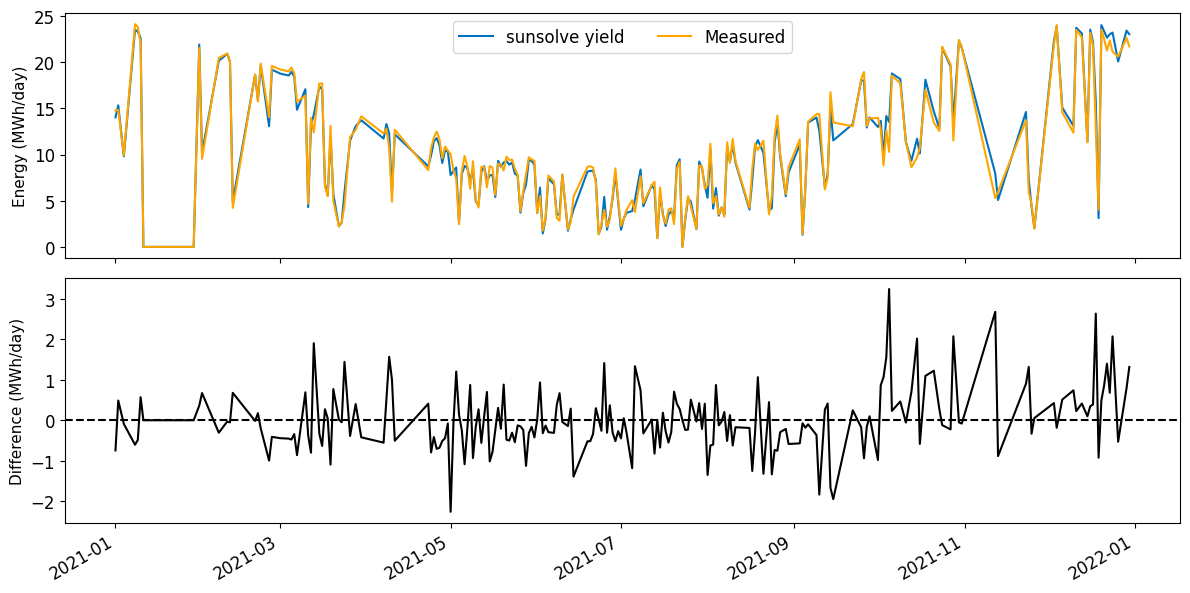


Evaluation Metrics:
MBE   : -0.000 MWh/day
MAE   : 0.538 MWh/day
RMSE  : 0.760 MWh/day
CRMSE : 0.760 MWh/day
CMAE  : 0.538 MWh/day
nRMSE : 3.147% (range)
NMAE  : 2.231% (range)
MAPE  : 7.313%

Seasonal Evaluation Metrics:

Autumn Metrics:
MBE  (Mean Bias Error): -0.155 MWh/day
RMSE (Root Mean Square Error): 0.718 MWh/day
CRMSE (Centered RMSE): 0.701 MWh/day
nRMSE (Normalized RMSE): 2.976%
NMAE (Normalized MAE): 2.358%
MAPE (Mean Absolute Percentage Error): 6.444%

Spring Metrics:
MBE  (Mean Bias Error): 0.236 MWh/day
RMSE (Root Mean Square Error): 1.122 MWh/day
CRMSE (Centered RMSE): 1.097 MWh/day
nRMSE (Normalized RMSE): 4.651%
NMAE (Normalized MAE): 3.327%
MAPE (Mean Absolute Percentage Error): 8.087%

Summer Metrics:
MBE  (Mean Bias Error): 0.195 MWh/day
RMSE (Root Mean Square Error): 0.657 MWh/day
CRMSE (Centered RMSE): 0.627 MWh/day
nRMSE (Normalized RMSE): 2.722%
NMAE (Normalized MAE): 1.650%
MAPE (Mean Absolute Percentage Error): 4.276%

Winter Metrics:
MBE  (Mean Bias Error): 

In [9]:
# Create a two-panel figure showing optimized results for filtered 2021 data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=long_hoz_figsize, sharex=True,
                              gridspec_kw={'height_ratios':[1,1]})

# Filter metrics_df to only include 2021 data - this ensures we use the same filtered data
# that was used for metrics calculation
filtered_2021_metrics = metrics_df[metrics_df.index.year == 2021].copy()
print(f"\n=== FILTERED 2021 DATA FOR PLOTTING ===")
print(f"Total days in filtered 2021 data: {len(filtered_2021_metrics)}")

if len(filtered_2021_metrics) > 0:
    # Plot only the filtered 2021 data with optimal scaling in top panel
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Simulated_display'], 
             label='sunsolve yield', color='#0072BF')
    
    # Plot the same filtered 2021 actual data
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Actual'], 
             label='Measured', color='orange')
    
    # Add labels and formatting for top panel
    ax1.set_ylabel('Energy (MWh/day)', fontsize=axis_label_size-4)
    ax1.legend(fontsize=text_size, loc='upper center', ncol=2)
    ax1.tick_params(labelsize=axis_num_size)
    
    # Calculate residuals (Simulated - Actual)
    residuals = filtered_2021_metrics['Simulated_display'] - filtered_2021_metrics['Actual']
    print("Mean difference:", residuals.mean())
    print("Median difference:", residuals.median())
    print('The difference is sunsolve yield - Measured')
    
    # Plot residuals in bottom panel
    ax2.plot(residuals.index, residuals, color='black', label='Difference')
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_ylabel('Difference (MWh/day)', fontsize=axis_label_size-4)
    # ax2.set_ylim(-100, 100)  # Same y-limits as example
    ax2.tick_params(labelsize=axis_num_size)
    
    # Add x-axis formatting
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    
    # Show plot
    plt.show()
    
    # Calculate additional metrics like the example
    mbe = residuals.mean()
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    crmse = np.sqrt(np.mean((residuals - mbe)**2))
    cmae = np.mean(np.abs(residuals - mbe))
    
    meas_range = filtered_2021_metrics['Actual'].max() - filtered_2021_metrics['Actual'].min()
    nrmse = rmse / meas_range * 100
    nmae = mae / meas_range * 100
    mape = np.mean(np.abs(residuals / filtered_2021_metrics['Actual'])) * 100
    
    # Print metrics
    print("\nEvaluation Metrics:")
    print(f"MBE   : {mbe:.3f} MWh/day")
    print(f"MAE   : {mae:.3f} MWh/day")
    print(f"RMSE  : {rmse:.3f} MWh/day")
    print(f"CRMSE : {crmse:.3f} MWh/day")
    print(f"CMAE  : {cmae:.3f} MWh/day")
    print(f"nRMSE : {nrmse:.3f}% (range)")
    print(f"NMAE  : {nmae:.3f}% (range)")
    print(f"MAPE  : {mape:.3f}%")
    
    # Seasonal metrics calculation
    df_season = pd.DataFrame({
        'sunsolve yield': filtered_2021_metrics['Simulated_display'],
        'Measured': filtered_2021_metrics['Actual']
    })
    df_season['Residual'] = df_season['sunsolve yield'] - df_season['Measured']
    
    # Define a function to determine the season for a given date (southern hemisphere)
    def get_season(date):
        month = date.month
        if month in [12, 1, 2]:
            return 'Summer'
        elif month in [3, 4, 5]:
            return 'Autumn'
        elif month in [6, 7, 8]:
            return 'Winter'
        elif month in [9, 10, 11]:
            return 'Spring'
    
    # Create a new column with the season for each day
    df_season['Season'] = df_season.index.to_series().apply(get_season)
    
    # Compute and print evaluation metrics for each season
    print("\nSeasonal Evaluation Metrics:")
    for season, group in df_season.groupby('Season'):
        season_mbe = group['Residual'].mean()
        season_rmse = np.sqrt(np.mean(group['Residual']**2))
        season_crmse = np.sqrt(np.mean((group['Residual'] - season_mbe)**2))
        season_nrmse = (season_rmse / meas_range) * 100
        season_nmae = (np.mean(np.abs(group['Residual'])) / meas_range) * 100
        season_mape = np.mean(np.abs(group['Residual'] / group['Measured'])) * 100
        print(f"\n{season} Metrics:")
        print("MBE  (Mean Bias Error): {:.3f} MWh/day".format(season_mbe))
        print("RMSE (Root Mean Square Error): {:.3f} MWh/day".format(season_rmse))
        print("CRMSE (Centered RMSE): {:.3f} MWh/day".format(season_crmse))
        print("nRMSE (Normalized RMSE): {:.3f}%".format(season_nrmse))
        print("NMAE (Normalized MAE): {:.3f}%".format(season_nmae))
        print("MAPE (Mean Absolute Percentage Error): {:.3f}%".format(season_mape))
    
    # Save the comparison plot to file
    # plot_file_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\sunsolve yield_vs_measured_comparison.png"
    # fig.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    # print(f"\nPlot saved to: {plot_file_path}")
    plt.show()
    
#     # Save the metrics to a text file
#     metrics_file_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\sunsolve yield_metrics.txt"
#     with open(metrics_file_path, 'w') as f:
#         f.write("EVALUATION METRICS\n")
#         f.write("=================\n\n")
#         f.write(f"Optimal scaling factor: {optimal_factor:.6f}\n")
#         f.write(f"Filtered data points: {len(filtered_2021_metrics)}\n\n")
#         f.write(f"MBE   : {mbe:.3f} MWh/day\n")
#         f.write(f"MAE   : {mae:.3f} MWh/day\n")
#         f.write(f"RMSE  : {rmse:.3f} MWh/day\n")
#         f.write(f"CRMSE : {crmse:.3f} MWh/day\n")
#         f.write(f"CMAE  : {cmae:.3f} MWh/day\n")
#         f.write(f"nRMSE : {nrmse:.3f}% (range)\n")
#         f.write(f"NMAE  : {nmae:.3f}% (range)\n")
#         f.write(f"MAPE  : {mape:.3f}%\n\n")
        
#         f.write("SEASONAL METRICS\n")
#         f.write("===============\n\n")
#         for season, group in df_season.groupby('Season'):
#             season_mbe = group['Residual'].mean()
#             season_rmse = np.sqrt(np.mean(group['Residual']**2))
#             season_crmse = np.sqrt(np.mean((group['Residual'] - season_mbe)**2))
#             season_nrmse = (season_rmse / meas_range) * 100
#             season_nmae = (np.mean(np.abs(group['Residual'])) / meas_range) * 100
#             season_mape = np.mean(np.abs(group['Residual'] / group['Measured'])) * 100
#             f.write(f"{season} Metrics:\n")
#             f.write("MBE  (Mean Bias Error): {:.3f} MWh/day\n".format(season_mbe))
#             f.write("RMSE (Root Mean Square Error): {:.3f} MWh/day\n".format(season_rmse))
#             f.write("CRMSE (Centered RMSE): {:.3f} MWh/day\n".format(season_crmse))
#             f.write("nRMSE (Normalized RMSE): {:.3f}%\n".format(season_nrmse))
#             f.write("NMAE (Normalized MAE): {:.3f}%\n".format(season_nmae))
#             f.write("MAPE (Mean Absolute Percentage Error): {:.3f}%\n\n".format(season_mape))
    
#     print(f"Metrics saved to: {metrics_file_path}")
    
# else:
#     print("\nERROR: No filtered data points from 2021 remain after filtering.")
#     print("Please check your maintenance-free days file and data availability.")

##### Montly optimised yeraly

=== MONTH-BY-MONTH OPTIMIZATION ===


January (26 days)
--------------------------------------------------
Optimal Factor: 361.469118
vs Annual Factor: 360.063164 (+0.39%)
MBE: 1.25e-14 MWh/day
RMSE: 0.265 MWh/day
nRMSE: 1.10%
MAPE: 2.53%

February (10 days)
--------------------------------------------------
Optimal Factor: 361.146730
vs Annual Factor: 360.063164 (+0.30%)
MBE: 3.74e-14 MWh/day
RMSE: 0.463 MWh/day
nRMSE: 2.77%
MAPE: 3.60%

March (21 days)
--------------------------------------------------
Optimal Factor: 361.686595
vs Annual Factor: 360.063164 (+0.45%)
MBE: -2.78e-14 MWh/day
RMSE: 0.725 MWh/day
nRMSE: 4.21%
MAPE: 5.91%

April (13 days)
--------------------------------------------------
Optimal Factor: 363.226337
vs Annual Factor: 360.063164 (+0.88%)
MBE: -2.58e-14 MWh/day
RMSE: 0.707 MWh/day
nRMSE: 8.94%
MAPE: 6.26%

May (31 days)
--------------------------------------------------
Optimal Factor: 371.782777
vs Annual Factor: 360.063164 (+3.25%)
MBE: -4.21e-14 MWh/day
RM

C:\Users\z5183876\AppData\Local\Temp\ipykernel_31664\2434682110.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


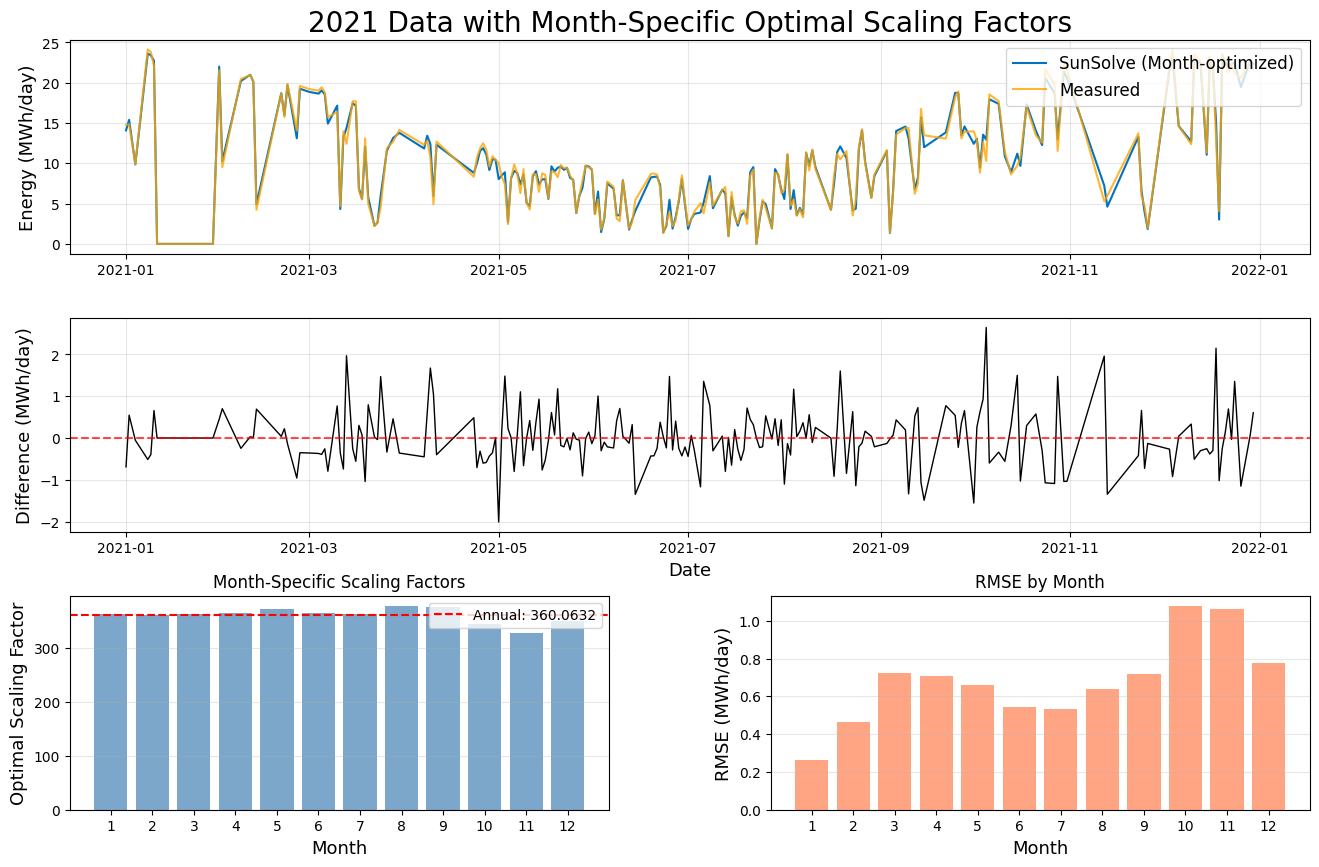


Month        Days   Factor     vs Annual    RMSE       nRMSE      MAPE      
January      26     361.469118      +0.39% 0.265      1.10      % 2.53      %
February     10     361.146730      +0.30% 0.463      2.77      % 3.60      %
March        21     361.686595      +0.45% 0.725      4.21      % 5.91      %
April        13     363.226337      +0.88% 0.707      8.94      % 6.26      %
May          31     371.782777      +3.25% 0.661      8.71      % 5.82      %
June         24     364.040227      +1.10% 0.546      7.40      % 9.81      %
July         26     361.590687      +0.42% 0.531      5.77      % 9.61      %
August       23     376.896215      +4.68% 0.636      5.81      % 6.72      %
September    15     374.384284      +3.98% 0.716      4.08      % 4.70      %
October      19     344.184204      -4.41% 1.078      7.82      % 7.00      %
November     6      327.553916      -9.03% 1.064      9.06      % 15.97     %
December     19     348.937645      -3.09% 0.776      3.88      

In [10]:
"""
Calculate month-specific optimal scaling factors and evaluation metrics for 2021 data.
Each month is optimized independently to minimize MBE.
"""

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 
    6: 'June', 7: 'July', 8: 'August', 9: 'September', 
    10: 'October', 11: 'November', 12: 'December'
}

# Filter metrics_df to only include 2021 data
filtered_2021_metrics = metrics_df[metrics_df.index.year == 2021].copy()

print("=== MONTH-BY-MONTH OPTIMIZATION ===\n")

# Dictionary to store month-specific results
month_results = {}

def calculate_monthly_mbe(month_data, scale_factor):
    """Calculate MBE for a specific month's data."""
    scaled_data = month_data['Simulated'] * scale_factor
    return np.mean(scaled_data - month_data['Actual'])

def find_monthly_optimal_scaling(month_data, month_num, min_factor=0.5, max_factor=2e10, max_iterations=100):
    """
    Find optimal scaling factor for a specific month using binary search.
    
    Parameters
    ----------
    month_data : pd.DataFrame
        DataFrame containing 'Simulated' and 'Actual' columns for the month
    month_num : int
        Month number (1-12)
    min_factor : float
        Minimum scaling factor to search
    max_factor : float
        Maximum scaling factor to search
    max_iterations : int
        Maximum number of binary search iterations
    
    Returns
    -------
    tuple
        (optimal_factor, final_mbe, iterations)
    """
    iterations = 0
    best_factor = None
    best_mbe = float('inf')
    
    while iterations < max_iterations:
        iterations += 1
        mid_factor = (min_factor + max_factor) / 2
        mbe = calculate_monthly_mbe(month_data, mid_factor)
        
        if abs(mbe) < abs(best_mbe):
            best_factor = mid_factor
            best_mbe = mbe
        
        if abs(mbe) < target_mbe_tolerance:
            return mid_factor, mbe, iterations
        
        # Adjust search bounds based on MBE sign
        if mbe > 0:
            max_factor = mid_factor
        else:
            min_factor = mid_factor
        
        if max_factor - min_factor < 1e-15:
            return best_factor, best_mbe, iterations
    
    return best_factor, best_mbe, iterations

# Optimize each month individually
for month_num in range(1, 13):
    month_data = filtered_2021_metrics[filtered_2021_metrics.index.month == month_num].copy()
    
    if len(month_data) < 1:
        print(f"{month_names[month_num]}: No data available")
        continue
    
    print(f"\n{month_names[month_num]} ({len(month_data)} days)")
    print("-" * 50)
    
    # Find optimal scaling factor for this month
    optimal_factor_month, final_mbe_month, iterations_month = find_monthly_optimal_scaling(
        month_data, month_num
    )
    
    # Apply optimal scaling
    month_data['Simulated_display'] = month_data['Simulated'] * optimal_factor_month
    
    # Calculate residuals
    residuals = month_data['Simulated_display'] - month_data['Actual']
    
    # Calculate evaluation metrics
    mbe = residuals.mean()
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    crmse = np.sqrt(np.mean((residuals - mbe)**2))
    
    meas_range = month_data['Actual'].max() - month_data['Actual'].min()
    nrmse = (rmse / meas_range * 100) if meas_range > 0 else 0
    nmae = (mae / meas_range * 100) if meas_range > 0 else 0
    
    # Avoid division by zero in MAPE
    non_zero_actual = month_data['Actual'] != 0
    if non_zero_actual.sum() > 0:
        mape = np.mean(np.abs(residuals[non_zero_actual] / month_data['Actual'][non_zero_actual])) * 100
    else:
        mape = 0
    
    # Store results
    month_results[month_num] = {
        'name': month_names[month_num],
        'days': len(month_data),
        'optimal_factor': optimal_factor_month,
        'iterations': iterations_month,
        'mbe': mbe,
        'mae': mae,
        'rmse': rmse,
        'crmse': crmse,
        'nrmse': nrmse,
        'nmae': nmae,
        'mape': mape,
        'data': month_data
    }
    
    print(f"Optimal Factor: {optimal_factor_month:.6f}")
    print(f"vs Annual Factor: {optimal_factor:.6f} ({((optimal_factor_month / optimal_factor) - 1) * 100:+.2f}%)")
    print(f"MBE: {mbe:.2e} MWh/day")
    print(f"RMSE: {rmse:.3f} MWh/day")
    print(f"nRMSE: {nrmse:.2f}%")
    print(f"MAPE: {mape:.2f}%")

# Create summary visualization
print("\n" + "=" * 80)
print("MONTHLY OPTIMIZATION SUMMARY")
print("=" * 80)

# Create a comprehensive figure with month-optimized data
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Reconstruct full year with month-optimized scaling
optimized_full_year = []
for month_num in range(1, 13):
    if month_num in month_results:
        optimized_full_year.append(month_results[month_num]['data'])

if optimized_full_year:
    optimized_2021_data = pd.concat(optimized_full_year).sort_index()
    
    # Top panel: Time series comparison
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(optimized_2021_data.index, optimized_2021_data['Simulated_display'], 
             label='SunSolve (Month-optimized)', color='#0072BF', linewidth=1.5)
    ax1.plot(optimized_2021_data.index, optimized_2021_data['Actual'], 
             label='Measured', color='orange', linewidth=1.5, alpha=0.8)
    ax1.set_ylabel('Energy (MWh/day)', fontsize=axis_label_size-2)
    ax1.legend(fontsize=text_size, loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('2021 Data with Month-Specific Optimal Scaling Factors', fontsize=title_size-2)
    
    # Middle panel: Residuals
    ax2 = fig.add_subplot(gs[1, :])
    residuals_full = optimized_2021_data['Simulated_display'] - optimized_2021_data['Actual']
    ax2.plot(optimized_2021_data.index, residuals_full, color='black', linewidth=1.0)
    ax2.axhline(0, color='red', linestyle='--', alpha=0.7)
    ax2.set_ylabel('Difference (MWh/day)', fontsize=axis_label_size-2)
    ax2.set_xlabel('Date', fontsize=axis_label_size-2)
    ax2.grid(True, alpha=0.3)
    
    # Bottom left: Scaling factors by month
    ax3 = fig.add_subplot(gs[2, 0])
    months = list(month_results.keys())
    factors = [month_results[m]['optimal_factor'] for m in months]
    ax3.bar(months, factors, color='steelblue', alpha=0.7)
    ax3.axhline(optimal_factor, color='red', linestyle='--', label=f'Annual: {optimal_factor:.4f}')
    ax3.set_xlabel('Month', fontsize=axis_label_size-2)
    ax3.set_ylabel('Optimal Scaling Factor', fontsize=axis_label_size-2)
    ax3.set_title('Month-Specific Scaling Factors', fontsize=text_size)
    ax3.legend(fontsize=text_size-2)
    ax3.set_xticks(months)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Bottom right: RMSE by month
    ax4 = fig.add_subplot(gs[2, 1])
    rmse_values = [month_results[m]['rmse'] for m in months]
    ax4.bar(months, rmse_values, color='coral', alpha=0.7)
    ax4.set_xlabel('Month', fontsize=axis_label_size-2)
    ax4.set_ylabel('RMSE (MWh/day)', fontsize=axis_label_size-2)
    ax4.set_title('RMSE by Month', fontsize=text_size)
    ax4.set_xticks(months)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive summary table
    print("\n" + "=" * 120)
    print(f"{'Month':<12} {'Days':<6} {'Factor':<10} {'vs Annual':<12} {'RMSE':<10} {'nRMSE':<10} {'MAPE':<10}")
    print("=" * 120)
    
    for month_num in sorted(month_results.keys()):
        result = month_results[month_num]
        factor_diff = ((result['optimal_factor'] / optimal_factor) - 1) * 100
        print(f"{result['name']:<12} {result['days']:<6} {result['optimal_factor']:<10.6f} "
              f"{factor_diff:>+10.2f}% {result['rmse']:<10.3f} {result['nrmse']:<10.2f}% {result['mape']:<10.2f}%")
    
    # Overall statistics for month-optimized approach
    overall_mbe = residuals_full.mean()
    overall_mae = np.abs(residuals_full).mean()
    overall_rmse = np.sqrt((residuals_full**2).mean())
    overall_crmse = np.sqrt(((residuals_full - overall_mbe)**2).mean())
    
    print("\n" + "=" * 120)
    print("OVERALL STATISTICS (Month-Optimized Approach)")
    print("=" * 120)
    print(f"Total days: {len(optimized_2021_data)}")
    print(f"MBE   : {overall_mbe:.3f} MWh/day")
    print(f"MAE   : {overall_mae:.3f} MWh/day")
    print(f"RMSE  : {overall_rmse:.3f} MWh/day")
    print(f"CRMSE : {overall_crmse:.3f} MWh/day")
    
    # Comparison with annual approach
    print("\n" + "=" * 120)
    print("COMPARISON: Month-Optimized vs Annual Single Factor")
    print("=" * 120)
    
    # Calculate metrics for annual single factor approach
    annual_scaled = filtered_2021_metrics['Simulated'] * optimal_factor
    annual_residuals = annual_scaled - filtered_2021_metrics['Actual']
    annual_rmse = np.sqrt((annual_residuals**2).mean())
    
    print(f"RMSE Improvement: {annual_rmse:.3f} → {overall_rmse:.3f} MWh/day ({((overall_rmse - annual_rmse) / annual_rmse * 100):+.2f}%)")
    print(f"MAE Improvement: {np.abs(annual_residuals).mean():.3f} → {overall_mae:.3f} MWh/day")

else:
    print("ERROR: No monthly data available for optimization")

##### Monthly


=== MONTH-SPECIFIC OPTIMIZATION FOR JANUARY ===
Optimizing scaling factor for January...
Data points available: 26
Iteration 1: Factor = 10000000000.2500000000, MBE = 1.3949155446e+08
Iteration 2: Factor = 5000000000.3750000000, MBE = 6.9745774714e+07
Iteration 3: Factor = 2500000000.4375000000, MBE = 3.4872884839e+07
Iteration 4: Factor = 1250000000.4687500000, MBE = 1.7436439902e+07
Iteration 5: Factor = 625000000.4843750000, MBE = 8.7182174334e+06
Iteration 6: Factor = 312500000.4921875000, MBE = 4.3591061991e+06
Iteration 7: Factor = 156250000.4960937500, MBE = 2.1795505819e+06
Iteration 8: Factor = 78125000.4980468750, MBE = 1.0897727734e+06
Iteration 9: Factor = 39062500.4990234375, MBE = 5.4488386907e+05
Iteration 10: Factor = 19531250.4995117188, MBE = 2.7243941693e+05
Iteration 20: Factor = 19073.9863276482, MBE = 2.6102382077e+02
Iteration 30: Factor = 354.4025783450, MBE = -9.8572268110e-02
Iteration 40: Factor = 361.4784471247, MBE = 1.3012897984e-04
Iteration 50: Factor =

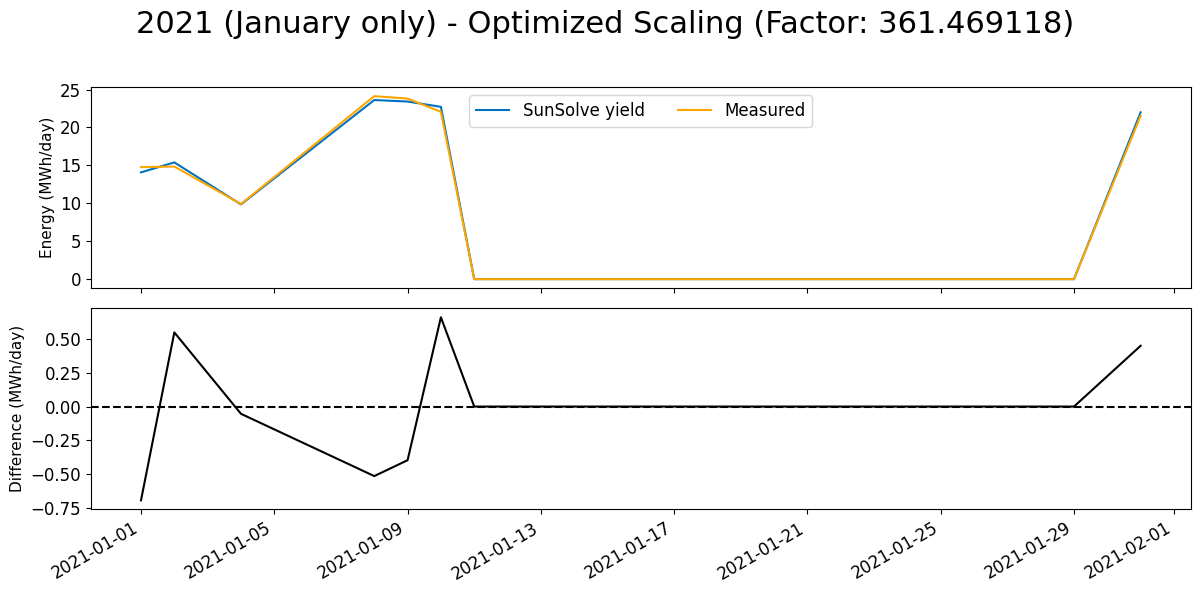


Evaluation Metrics for 2021 (January only):
MBE   : 0.000 MWh/day
MAE   : 0.127 MWh/day
RMSE  : 0.265 MWh/day
CRMSE : 0.265 MWh/day
CMAE  : 0.127 MWh/day
nRMSE : 1.099% (range)
NMAE  : 0.526% (range)
MAPE  : 2.533%


In [11]:
# Add this parameter at the beginning of your cell
selected_month = 1  # 1 for January, None for all months
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 
               6: 'June', 7: 'July', 8: 'August', 9: 'September', 
               10: 'October', 11: 'November', 12: 'December'}

# Filter metrics_df to only include 2021 data
filtered_2021_metrics = metrics_df[metrics_df.index.year == 2021].copy()

# Apply month filtering if selected_month is specified
if selected_month is not None:
    month_filtered_metrics = filtered_2021_metrics[filtered_2021_metrics.index.month == selected_month].copy()
    month_label = f" ({month_names[selected_month]} only)"
    
    # Calculate month-specific optimal scaling factor
    print(f"\n=== MONTH-SPECIFIC OPTIMIZATION FOR {month_names[selected_month].upper()} ===")
    
    def calculate_month_mbe(scale_factor):
        """Calculate MBE for the selected month"""
        scaled_data = month_filtered_metrics['Simulated'] * scale_factor
        return np.mean(scaled_data - month_filtered_metrics['Actual'])
    
    def find_month_optimal_scaling(min_factor=0.5, max_factor=2e10, max_iterations=100):
        """Find optimal scaling factor for the selected month"""
        print(f"Optimizing scaling factor for {month_names[selected_month]}...")
        print(f"Data points available: {len(month_filtered_metrics)}")
        
        iterations = 0
        best_factor = None
        best_mbe = float('inf')
        
        while iterations < max_iterations:
            iterations += 1
            mid_factor = (min_factor + max_factor) / 2
            mbe = calculate_month_mbe(mid_factor)
            
            if abs(mbe) < abs(best_mbe):
                best_factor = mid_factor
                best_mbe = mbe
            
            if iterations % 10 == 0 or iterations < 10:
                print(f"Iteration {iterations}: Factor = {mid_factor:.10f}, MBE = {mbe:.10e}")
            
            if abs(mbe) < target_mbe_tolerance:
                print(f"✓ Converged! Month-specific MBE below tolerance.")
                return mid_factor, mbe, iterations
            
            if mbe > 0:
                max_factor = mid_factor
            else:
                min_factor = mid_factor
            
            if max_factor - min_factor < 1e-15:
                print(f"! Reached numerical precision limit.")
                return best_factor, best_mbe, iterations
        
        return best_factor, best_mbe, iterations
    
    # Find month-specific optimal scaling
    month_optimal_factor, month_final_mbe, month_iterations = find_month_optimal_scaling()
    
    print(f"\n=== {month_names[selected_month].upper()} OPTIMIZATION RESULTS ===")
    print(f"Month-specific optimal factor: {month_optimal_factor:.10f}")
    print(f"Annual optimal factor: {optimal_factor:.10f}")
    print(f"Difference: {((month_optimal_factor / optimal_factor) - 1) * 100:+.2f}%")
    print(f"Final MBE: {month_final_mbe:.12e} MWh/day")
    print(f"Iterations: {month_iterations}")
    
    # Apply month-specific scaling
    month_filtered_metrics['Simulated_display'] = month_filtered_metrics['Simulated'] * month_optimal_factor
    filtered_2021_metrics = month_filtered_metrics
    
else:
    month_label = ""
    # Use annual optimal scaling for all months
    filtered_2021_metrics['Simulated_display'] = filtered_2021_metrics['Simulated'] * optimal_factor
    print(f"\n=== USING ANNUAL OPTIMAL SCALING ===")
    print(f"Annual optimal factor: {optimal_factor:.10f}")

print(f"\n=== FILTERED 2021{month_label} DATA FOR PLOTTING ===")
print(f"Total days in filtered 2021{month_label} data: {len(filtered_2021_metrics)}")

if len(filtered_2021_metrics) > 0:
    # Create a two-panel figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=long_hoz_figsize, sharex=True,
                                  gridspec_kw={'height_ratios':[1,1]})
    
    # Plot the scaled simulation data
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Simulated_display'], 
             label='SunSolve yield', color='#0072BF')
    
    # Plot the actual data
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Actual'], 
             label='Measured', color='orange')
    
    # Add labels and formatting for top panel
    ax1.set_ylabel('Energy (MWh/day)', fontsize=axis_label_size-4)
    ax1.legend(fontsize=text_size, loc='upper center', ncol=2)
    ax1.tick_params(labelsize=axis_num_size)
    
    # Calculate residuals
    residuals = filtered_2021_metrics['Simulated_display'] - filtered_2021_metrics['Actual']
    
    # Plot residuals in bottom panel
    ax2.plot(residuals.index, residuals, color='black', label='Difference')
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_ylabel('Difference (MWh/day)', fontsize=axis_label_size-4)
    ax2.tick_params(labelsize=axis_num_size)
    
    # Add title with scaling info
    if selected_month is not None:
        title = f'2021{month_label} - Optimized Scaling (Factor: {month_optimal_factor:.6f})'
    else:
        title = f'2021 Full Year - Annual Optimal Scaling (Factor: {optimal_factor:.6f})'
    fig.suptitle(title, fontsize=title_size)
    
    # Format and show
    plt.gcf().autofmt_xdate()
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # Calculate error metrics
    mbe = residuals.mean()
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    crmse = np.sqrt(np.mean((residuals - mbe)**2))
    cmae = np.mean(np.abs(residuals - mbe))
    
    meas_range = filtered_2021_metrics['Actual'].max() - filtered_2021_metrics['Actual'].min()
    nrmse = rmse / meas_range * 100
    nmae = mae / meas_range * 100
    mape = np.mean(np.abs(residuals / filtered_2021_metrics['Actual'])) * 100
    
    print(f"\nEvaluation Metrics for 2021{month_label}:")
    print(f"MBE   : {mbe:.3f} MWh/day")
    print(f"MAE   : {mae:.3f} MWh/day")
    print(f"RMSE  : {rmse:.3f} MWh/day")
    print(f"CRMSE : {crmse:.3f} MWh/day")
    print(f"CMAE  : {cmae:.3f} MWh/day")
    print(f"nRMSE : {nrmse:.3f}% (range)")
    print(f"NMAE  : {nmae:.3f}% (range)")
    print(f"MAPE  : {mape:.3f}%")
    
else:
    print(f"\nERROR: No filtered data points from 2021{month_label} remain after filtering.")